# LLM-Driven Bayesian Modeling Tool for Reliability & Predictive Maintenance
### RAMS 2027 Tutorial — Kirtis Christensen

**Using Hubbard's Applied Information Economics (AIE) + Large Language Models**

---

## How to Use This Notebook

Run cells **top to bottom**. Each section corresponds to one AIE step.  
At each `## YOUR TURN` block, substitute your own problem description or data.

**What you will produce by the end:**
- A structured JSON decomposition of your reliability problem
- Value of Information (VoI) ranking of your measurements
- A calibrated Bayesian model with prior → likelihood → posterior
- A Monte Carlo simulation and decision recommendation

---

### Tutorial Sections

| # | Section | AIE Step |
|---|---------|----------|
| 1 | Environment Setup | — |
| 2 | Background: AIE + Bayesian Concepts | Framing |
| 3 | Step 1 — Define the Decision & Uncertainty | AIE Step 1 |
| 4 | Step 2 — LLM Problem Parser → JSON | AIE Step 2 |
| 5 | Step 3 — Value of Information (VoI) Ranking | AIE Step 3 |
| 6 | Step 4 — Calibrated Priors (Two Paths) | AIE Step 4 |
| 7 | Step 5 — Bayesian Update (Likelihood + Posterior) | AIE Step 5 |
| 8 | Step 6 — Chained Bayesian DAG Visualization | AIE Step 5 |
| 9 | Step 7 — Monte Carlo Simulation & Decision | AIE Step 5 |
|10 | Your Turn — Participant Exercise | All Steps |

---
## Section 1 — Environment Setup

Run this cell once to install required packages.  
On **Google Colab**: this works immediately with no local configuration.

In [354]:
# Install required packages (safe to re-run)
# Uses uv when available (required for uv-managed .venv); falls back to pip (Colab etc.)
import subprocess, sys, shutil, os, importlib.util

packages = [
    "numpy", "scipy", "pandas", "matplotlib", "seaborn",
    "networkx",       # DAG visualization
    "openai",         # LLM API (OpenAI-compatible; swap for any provider)
    "pymc",           # Bayesian inference
    "arviz",          # Posterior diagnostics
    "ipywidgets",     # Interactive sliders
]

# Only install packages that are actually missing
missing = [pkg for pkg in packages if importlib.util.find_spec(pkg) is None]
if missing:
    print(f'Installing missing packages: {missing}')
    uv_candidates = [
        shutil.which('uv'),
        os.path.join(os.path.expanduser('~'), '.local', 'bin', 'uv.exe'),
        os.path.join(os.path.expanduser('~'), '.local', 'bin', 'uv'),
    ]
    uv_exe = next((p for p in uv_candidates if p and os.path.isfile(p)), None)
    if uv_exe:
        subprocess.check_call([uv_exe, 'pip', 'install', '--python', sys.executable] + missing)
    else:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install'] + missing)
else:
    print('All packages already installed — skipping.')

print('All packages ready.')

All packages already installed — skipping.
All packages ready.


In [355]:
# Core imports
import os, json, textwrap
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
import pymc as pm
import arviz as az
import ipywidgets as widgets
from IPython.display import display, Markdown, JSON

# Plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

print(f"PyMC version: {pm.__version__}")
print(f"ArviZ version: {az.__version__}")
print("Environment ready.")

PyMC version: 5.28.5
ArviZ version: 0.23.4
Environment ready.


### Configure Your Runtime LLM Options

This tutorial supports two provider paths:
- OpenAI cloud using `OPENAI_API_KEY` (or facilitator-provided `WORKSHOP_OPENAI_API_KEY`)
- Ollama local endpoint at `OLLAMA_BASE_URL` (no cloud API key required)

Run order in this section:
1. Configure provider and client.
2. Optionally run API connection check.
3. Run runtime preflight diagnosis before parser call.

In [356]:
# -- LLM CONFIGURATION ---------------------------------------------------------
# This notebook uses an OpenAI-compatible provider API endpoint.
# Supported here: OpenAI cloud and Ollama local endpoint.


from openai import OpenAI

PROVIDER = os.environ.get("LLM_PROVIDER", "openai").lower()  # "openai" or "ollama"

openai_personal_key = os.environ.get("OPENAI_API_KEY", "").strip()
workshop_key = os.environ.get("WORKSHOP_OPENAI_API_KEY", "").strip()

if PROVIDER == "openai":
    API_KEY = openai_personal_key or workshop_key or "YOUR_KEY_HERE"
    BASE_URL = "https://api.openai.com/v1"
    MODEL = os.environ.get("LLM_MODEL", "gpt-4o-mini")
    if openai_personal_key:
        key_source = "OPENAI_API_KEY"
    elif workshop_key:
        key_source = "WORKSHOP_OPENAI_API_KEY"
    else:
        key_source = "placeholder"
elif PROVIDER == "ollama":
    API_KEY = os.environ.get("OLLAMA_API_KEY", "ollama")
    BASE_URL = os.environ.get("OLLAMA_BASE_URL", "http://localhost:11434/v1")
    MODEL = os.environ.get("LLM_MODEL", "llama3.1")
    key_source = "local (no cloud key required)"
else:
    raise ValueError("Unsupported PROVIDER. Use 'openai' or 'ollama'.")

# -- DIRECT-KEY OVERRIDE (optional quick demo path) -----------------------------
# API_KEY = "sk-PASTE-YOUR-OPENAI-KEY-HERE"

client = OpenAI(api_key=API_KEY, base_url=BASE_URL)

print(f"Provider: {PROVIDER}")
print(f"LLM configured: {MODEL} @ {BASE_URL}")
print(f"Credential source: {key_source}")
print(f"API_KEY loaded: length={len(API_KEY) if API_KEY else 0}, starts with {API_KEY[:4]!r}")

def _optional_api_connection_check() -> None: 
    # -- OPTIONAL API CONNECTION CHECK ----------------------------------------------
    # Run this after the config cell to verify provider and model before full parsing.

    print(f"Provider: {PROVIDER}  |  Model: {MODEL}")
    print(f"Key length: {len(API_KEY) if API_KEY else 0}  | starts with: {API_KEY[:4] if API_KEY else ''!r}")

    if PROVIDER == "openai":
        if (not API_KEY) or API_KEY.strip() in ("", "YOUR_KEY_HERE") or API_KEY.strip().startswith("YOUR_"):
            raise ValueError(
                "OpenAI key is still a placeholder. Set OPENAI_API_KEY (personal) or "
                "WORKSHOP_OPENAI_API_KEY (facilitator key), then re-run config and this check."
            )

    if PROVIDER == "ollama":
        print("Ollama path selected: make sure Ollama is running and model is pulled locally.")
        print("Example: ollama pull llama3.1")

    try:
        test_response = client.chat.completions.create(
            model=MODEL,
            messages=[
                {"role": "user", "content": "Reply with exactly: API connection ok"}
            ],
            temperature=0,
            max_tokens=10,
        )
        print(test_response.choices[0].message.content)
        print(f"API check passed for provider={PROVIDER}, model={MODEL}.")
    except Exception as error:
        print(f"API check failed for provider={PROVIDER}, model={MODEL}: {type(error).__name__}: {error}")
        raise

def _optional_runtime_preflight_check() -> None:
    # -- RUNTIME PREFLIGHT CHECK ----------------------------------------------------
    # Diagnose which execution paths are available before parser call.

    runtime_modes = []

    openai_key = os.environ.get("OPENAI_API_KEY", "").strip()
    workshop_key = os.environ.get("WORKSHOP_OPENAI_API_KEY", "").strip()
    ollama_base_url = os.environ.get("OLLAMA_BASE_URL", "http://localhost:11434/v1")

    has_personal_key = bool(openai_key) and (not openai_key.startswith("YOUR"))
    has_workshop_key = bool(workshop_key) and (not workshop_key.startswith("YOUR"))
    ollama_selected = PROVIDER == "ollama"

    if has_personal_key:
        runtime_modes.append("✓ OpenAI (personal API key detected)")
    else:
        runtime_modes.append("✗ OpenAI personal key not detected")

    if has_workshop_key:
        runtime_modes.append("✓ Workshop temporary key detected")
    else:
        runtime_modes.append("✗ Workshop temporary key not detected")

    if ollama_selected:
        runtime_modes.append(f"✓ Ollama local mode selected ({ollama_base_url})")
    else:
        runtime_modes.append("- Ollama local mode not selected")

    runtime_modes.append("✓ Offline fallback (OFFLINE_JSON always available)")

    display(Markdown("## Runtime Preflight Diagnosis"))
    for mode in runtime_modes:
        display(Markdown(f"- {mode}"))

    print()
    if (PROVIDER == "openai" and (has_personal_key or has_workshop_key)) or ollama_selected:
        print("Status: LLM parser is ready to run.")
    else:
        print("Status: No live provider credential detected. Use OFFLINE_JSON fallback.")

Provider: openai
LLM configured: gpt-4o-mini @ https://api.openai.com/v1
Credential source: OPENAI_API_KEY
API_KEY loaded: length=164, starts with 'sk-p'


In [357]:
# Options checks
_optional_api_connection_check()
_optional_runtime_preflight_check()

Provider: openai  |  Model: gpt-4o-mini
Key length: 164  | starts with: 'sk-p'
API connection ok
API check passed for provider=openai, model=gpt-4o-mini.


## Runtime Preflight Diagnosis

- ✓ OpenAI (personal API key detected)

- ✗ Workshop temporary key not detected

- - Ollama local mode not selected

- ✓ Offline fallback (OFFLINE_JSON always available)


Status: LLM parser is ready to run.


### Define Reusable data structures and functions

In [381]:
#REUSABLE DATA STRUCTURES AND FUNCTIONS GO HERE

# ── CANONICAL BAYESIAN MODEL JSON SCHEMA ──────────────────────────────────────
# Increment A Deliverable #1: Define the contract for all model JSON.
# All LLM-generated and offline fallback JSON must validate against this schema.

CANONICAL_MODEL_SCHEMA = {
    'required_top_level_keys': [
        'schema_version', 'profile', 'problem_summary', 'decision', 'measurement_nodes',
        'bayesian_update_chain', 'voi_candidates', 'model_notes'
    ],
    'measurement_node_required_fields': [
        'name', 'description', 'role', 'distribution_family',
        'distribution_parameters', 'justification', 'data_source', 'depends_on'
    ],
    'valid_roles': [
        'prior', 'likelihood', 'posterior', 'decision_variable', 'cost_node',
        'observed_data',  # LLMs sometimes use this for observed evidence nodes
    ],
    'valid_distribution_families': [
        'Normal', 'Gamma', 'Beta', 'Poisson', 'Exponential',
        'Weibull', 'Lognormal', 'Uniform', 'HalfNormal', 'Binomial',
        'Constant',           # fixed/observed value node
        'TruncatedNormal', 'StudentT', 'Cauchy', 'LogNormal',
        'NegativeBinomial', 'BetaBinomial', 'ZeroInflatedPoisson',
        # Discrete / multi-outcome families used by decision variables and
        # categorical priors. The dynamic builder still only auto-builds the
        # Gamma-Poisson family; these validate so the LLM output is accepted
        # and downstream cells either consume them or fall back as today.
        'Categorical', 'Bernoulli', 'DiscreteUniform', 'Multinomial',
        'Dirichlet', 'MvNormal',
        'derived_from_simulation'
    ],
    'valid_data_sources': ['expert_estimate', 'observed_data', 'derived'],
    'valid_profiles': ['reliability']
}

print('✓ Canonical schema frozen and loaded.')

# -- DECISION FRAME --------------------------------------------------------------
# Baseline configuration and reusable scenario library for Section 3.
# Downstream sections continue to read `decision_frame`.
#
# `pm_cycle_months` is the cadence of the *strategic* (planned-intervention)
# decision option in decision_options[0]. It drives the per-cycle exposure
# window in build_default_offline_json and in Section5_Step3_Compute_VoI.

SCENARIO_LIBRARY = {
    "Pump - Preventive vs Reactive": {
        "problem_description": """
            A centrifugal pump at a water treatment facility has experienced 3 failures
            in 24 months of operation. Each unplanned failure costs $18,000 in repairs
            and lost production. A preventive maintenance (PM) intervention costs $2,200.
            Historical industry data suggests mean time between failures (MTBF) for this
            pump class is 9-14 months under similar conditions, but our data is limited.
            We want to decide whether to implement a 6-month PM schedule or continue
            run-to-failure maintenance for the next 12 months.
        """,
        "decision_options": [
            "Implement 6-month preventive maintenance schedule",
            "Continue run-to-failure (reactive maintenance only)",
        ],
        "objective": "Minimize expected total maintenance cost over 12 months",
        "time_horizon_months": 12,
        "cost_pm_per_intervention_usd": 2200,
        "cost_unplanned_failure_usd": 18000,
        "observed_failures": 3,
        "observation_period_months": 24,
        "industry_mtbf_range_months": [9, 14],
        "pm_cycle_months": 6,
    },
    "Conveyor - Predictive vs Scheduled": {
        "problem_description": """
            A conveyor gearbox has failed 5 times in the last 18 months. Each unplanned
            failure costs $28,000 in downtime and repairs. A scheduled intervention costs
            $4,500. We need to decide whether to run quarterly predictive maintenance or
            keep a fixed 6-month schedule for the next 12 months.
        """,
        "decision_options": [
            "Quarterly predictive maintenance",
            "Fixed 6-month scheduled maintenance",
        ],
        "objective": "Minimize expected total maintenance cost over 12 months",
        "time_horizon_months": 12,
        "cost_pm_per_intervention_usd": 4500,
        "cost_unplanned_failure_usd": 28000,
        "observed_failures": 5,
        "observation_period_months": 18,
        "industry_mtbf_range_months": [5, 10],
        "pm_cycle_months": 3,
    },
    "Safety Valve - Inspection Interval": {
        "problem_description": """
            A safety valve has had 0 failures in 36 months. An inspection costs $1,200,
            while a failure event is estimated at $150,000. Decide whether to keep annual
            inspection or move to 18-month inspection over a 36-month horizon.
        """,
        "decision_options": [
            "Annual inspection",
            "18-month inspection",
        ],
        "objective": "Minimize expected total risk-adjusted maintenance cost",
        "time_horizon_months": 36,
        "cost_pm_per_intervention_usd": 1200,
        "cost_unplanned_failure_usd": 150000,
        "observed_failures": 0,
        "observation_period_months": 36,
        "industry_mtbf_range_months": [18, 60],
        "pm_cycle_months": 12,
    },
}

# Single source of scenario truth used by all downstream sections.
SCENARIO_CONFIG = dict(SCENARIO_LIBRARY["Pump - Preventive vs Reactive"])

# Safe default for non-widget environments.
decision_frame = dict(SCENARIO_CONFIG)

print("Scenario library loaded.")
print(f"Default scenario: Pump - Preventive vs Reactive")
print("Run the next cell to configure parameters interactively.")

# ── SYSTEM PROMPT — Bayesian Model Engineer ────────────────────────────────────
SYSTEM_PROMPT = """
You are an expert Bayesian reliability engineer and statistician.
Given a natural-language reliability problem description, you must:

1. Identify all uncertain quantities (measurement nodes).
2. For each node, specify:
   - name: short identifier (snake_case)
   - description: plain-English explanation of what it represents
   - role: one of ["prior", "likelihood", "posterior", "decision_variable", "cost_node"]
   - distribution_family: e.g. Gamma, Weibull, Beta, Normal, Poisson, Exponential
   - distribution_parameters: dict of parameter names and initial values or ranges
   - justification: WHY this distribution family is correct for this node
   - data_source: "expert_estimate", "observed_data", or "derived"
   - depends_on: list of node names this node depends on (empty list if root node)
3. Identify the key Bayesian update chain as an ordered list of node names.
4. Return ONLY valid JSON. No markdown fences, no explanation outside the JSON.

JSON schema:
{
    "schema_version": "string (e.g., 1.0)",
    "profile": "reliability",
  "problem_summary": "string",
  "decision": "string",
  "measurement_nodes": [ { ...node fields... } ],
  "bayesian_update_chain": ["node_name", ...],
  "voi_candidates": ["node_name", ...],
  "model_notes": "string"
}
"""

def parse_problem_to_json(problem_text: str) -> dict:
    """Send problem description to LLM and return structured Bayesian JSON."""
    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": problem_text}
        ],
        temperature=0.1,   # Low temperature for deterministic structured output
        response_format={"type": "json_object"},
    )
    model_json = json.loads(response.choices[0].message.content)
    # Backward-compatible normalization for older prompts/responses.
    model_json.setdefault("schema_version", "1.0")
    model_json.setdefault("profile", "reliability")
    return model_json

print("LLM parser function defined.")

# ── SCHEMA VALIDATION FUNCTION ────────────────────────────────────────────────
# Increment A Deliverable #3: Validate model JSON before downstream use.

def validate_bayesian_model_json(model_json: dict) -> tuple:
    """
    Validate parsed or offline JSON against canonical schema.
    Returns (is_valid: bool, errors: list[str])
    """
    errors = []
    
    # Check top-level keys
    for key in CANONICAL_MODEL_SCHEMA['required_top_level_keys']:
        if key not in model_json:
            errors.append(f'Missing required key: {key}')

    # Check schema metadata
    if 'schema_version' in model_json and not isinstance(model_json['schema_version'], str):
        errors.append('schema_version must be a string, e.g., "1.0"')
    if 'profile' in model_json:
        if model_json['profile'] not in CANONICAL_MODEL_SCHEMA['valid_profiles']:
            errors.append(f'Invalid profile: {model_json["profile"]}')
    
    # Check measurement nodes structure
    if 'measurement_nodes' in model_json:
        nodes = model_json['measurement_nodes']
        if not isinstance(nodes, list):
            errors.append('measurement_nodes must be a list')
        else:
            node_names = set()
            for i, node in enumerate(nodes):
                # Check required fields
                for field in CANONICAL_MODEL_SCHEMA['measurement_node_required_fields']:
                    if field not in node:
                        errors.append(f'Node {i} ({node.get("name", "?")}): missing field {field}')
                
                # Check uniqueness
                if 'name' in node:
                    if node['name'] in node_names:
                        errors.append(f'Duplicate node name: {node["name"]}')
                    node_names.add(node['name'])
                
                # Check role validity
                if 'role' in node and node['role'] not in CANONICAL_MODEL_SCHEMA['valid_roles']:
                    errors.append(f'Node {i}: invalid role "{node["role"]}"')
                
                # Check distribution validity
                if 'distribution_family' in node and node['distribution_family'] not in CANONICAL_MODEL_SCHEMA['valid_distribution_families']:
                    errors.append(f'Node {i}: unknown distribution "{node["distribution_family"]}"')
    
    return (len(errors) == 0, errors)

print('✓ Schema validator function defined.')

# ── PROCEDURAL OFFLINE FALLBACK BUILDER ───────────────────────────────────────
# Builds a Gamma-Poisson reliability model JSON for ANY decision_frame-shaped
# config (any scenario in SCENARIO_LIBRARY, edits via Section 3 widgets, or a
# user-supplied my_decision_frame). Used as the offline fallback when the LLM
# is unavailable or returns invalid JSON. Output validates against
# CANONICAL_MODEL_SCHEMA and matches the scenario currently in decision_frame.

def build_default_offline_json(cfg: dict, pm_cycle_months: int = None) -> dict:
    """
    Construct a Gamma-Poisson reliability model JSON derived from `cfg`
    (a decision_frame-shaped dict). All measurement nodes, parameters, and
    cost fields are computed from cfg so the fallback always matches the
    user's currently-selected scenario.

    `pm_cycle_months` may be passed explicitly; if omitted, falls back to
    `cfg["pm_cycle_months"]` and then to a 6-month default.
    """
    from scipy.optimize import minimize

    horizon       = int(cfg["time_horizon_months"])
    obs_failures  = int(cfg["observed_failures"])
    obs_months    = int(cfg["observation_period_months"])
    mtbf_lo, mtbf_hi = cfg["industry_mtbf_range_months"]
    cost_pm       = cfg["cost_pm_per_intervention_usd"]
    cost_fail     = cfg["cost_unplanned_failure_usd"]
    objective     = cfg.get("objective", "Minimize expected cost over the planning horizon")
    problem_desc  = (cfg.get("problem_description") or "").strip()
    if pm_cycle_months is None:
        pm_cycle_months = int(cfg.get("pm_cycle_months", 6))

    # Convert MTBF 90% CI -> lambda 90% CI, then fit Gamma(alpha, beta=rate)
    # so its 5th/95th percentiles bracket the lambda CI.
    lam_lo = 1.0 / float(mtbf_hi)
    lam_hi = 1.0 / float(mtbf_lo)

    def _gamma_ci_loss(p):
        a, b = p
        if a <= 0 or b <= 0:
            return 1e10
        p5  = stats.gamma.ppf(0.05, a=a, scale=1.0 / b)
        p95 = stats.gamma.ppf(0.95, a=a, scale=1.0 / b)
        return (p5 - lam_lo) ** 2 + (p95 - lam_hi) ** 2

    res = minimize(_gamma_ci_loss, x0=[3.0, 30.0], method="Nelder-Mead")
    alpha_prior, beta_prior = float(res.x[0]), float(res.x[1])

    # Conjugate Gamma-Poisson posterior.
    alpha_post = alpha_prior + obs_failures
    beta_post  = beta_prior + obs_months

    # PM cadence and resulting planned-intervention count over the horizon.
    pm_cycle = max(1, int(pm_cycle_months))
    n_pm     = max(1, horizon // pm_cycle)

    # First non-empty line of the problem description as a short summary.
    summary_line = next(
        (line.strip() for line in problem_desc.splitlines() if line.strip()),
        "Reliability decision derived from supplied decision_frame.",
    )

    return {
        "schema_version": "1.0",
        "profile": "reliability",
        "problem_summary": summary_line,
        "decision": objective,
        "measurement_nodes": [
            {
                "name": "failure_rate_lambda",
                "description": "True underlying failure rate (events per month)",
                "role": "prior",
                "distribution_family": "Gamma",
                "distribution_parameters": {
                    "alpha": round(alpha_prior, 4),
                    "beta": round(beta_prior, 4),
                },
                "justification": (
                    f"Gamma is the conjugate prior for a Poisson failure process. "
                    f"alpha/beta fit so the 90% CI on lambda matches MTBF range "
                    f"[{mtbf_lo}, {mtbf_hi}] months."
                ),
                "data_source": "expert_estimate",
                "depends_on": [],
            },
            {
                "name": "observed_failures",
                "description": f"Observed failure count: {obs_failures} failures in {obs_months} months",
                "role": "likelihood",
                "distribution_family": "Poisson",
                "distribution_parameters": {"mu": f"failure_rate_lambda * {obs_months}"},
                "justification": "Poisson likelihood for independent count data over a fixed exposure window.",
                "data_source": "observed_data",
                "depends_on": ["failure_rate_lambda"],
            },
            {
                "name": "posterior_failure_rate",
                "description": "Updated belief about lambda after conditioning on observed failures",
                "role": "posterior",
                "distribution_family": "Gamma",
                "distribution_parameters": {
                    "alpha": round(alpha_post, 4),
                    "beta": round(beta_post, 4),
                },
                "justification": (
                    f"Gamma-Poisson conjugacy: posterior Gamma(alpha + k, beta + t) = "
                    f"Gamma({alpha_prior:.2f}+{obs_failures}, {beta_prior:.2f}+{obs_months})."
                ),
                "data_source": "derived",
                "depends_on": ["failure_rate_lambda", "observed_failures"],
            },
            {
                "name": "failures_next_window_pm",
                "description": (
                    f"Predicted failures over a {pm_cycle}-month PM cycle "
                    f"(effective exposure resets at each intervention)"
                ),
                "role": "decision_variable",
                "distribution_family": "Poisson",
                "distribution_parameters": {"mu": f"posterior_failure_rate * {pm_cycle}"},
                "justification": (
                    f"Under a {pm_cycle}-month PM cadence, effective exposure between "
                    f"interventions is {pm_cycle} months."
                ),
                "data_source": "derived",
                "depends_on": ["posterior_failure_rate"],
            },
            {
                "name": "failures_next_horizon_rtf",
                "description": (
                    f"Predicted failures over the full {horizon}-month horizon "
                    f"under run-to-failure"
                ),
                "role": "decision_variable",
                "distribution_family": "Poisson",
                "distribution_parameters": {"mu": f"posterior_failure_rate * {horizon}"},
                "justification": "Full horizon exposure with no preventive interventions.",
                "data_source": "derived",
                "depends_on": ["posterior_failure_rate"],
            },
            {
                "name": "total_cost_pm",
                "description": f"Total cost under PM: {n_pm} planned interventions + unplanned failures",
                "role": "cost_node",
                "distribution_family": "derived_from_simulation",
                "distribution_parameters": {
                    "pm_interventions": n_pm,
                    "cost_pm": cost_pm,
                    "cost_failure": cost_fail,
                },
                "justification": (
                    f"{n_pm} planned PMs x PM cost + expected unplanned failures x failure cost."
                ),
                "data_source": "derived",
                "depends_on": ["failures_next_window_pm"],
            },
            {
                "name": "total_cost_rtf",
                "description": "Total cost under run-to-failure: all costs from unplanned failures",
                "role": "cost_node",
                "distribution_family": "derived_from_simulation",
                "distribution_parameters": {"cost_failure": cost_fail},
                "justification": "No planned interventions; all maintenance cost from unplanned failures.",
                "data_source": "derived",
                "depends_on": ["failures_next_horizon_rtf"],
            },
        ],
        "bayesian_update_chain": [
            "failure_rate_lambda",
            "observed_failures",
            "posterior_failure_rate",
            "failures_next_window_pm",
            "failures_next_horizon_rtf",
            "total_cost_pm",
            "total_cost_rtf",
        ],
        "voi_candidates": ["failure_rate_lambda", "posterior_failure_rate"],
        "model_notes": (
            "Gamma-Poisson conjugate template auto-built from decision_frame. "
            "Posterior is analytical; cost nodes are evaluated by Monte Carlo in Section 9."
        ),
    }

# Seed module-level OFFLINE_JSON for the default scenario so downstream cells
# that reference OFFLINE_JSON (Increment B dynamic builder, DAG visualisation)
# always have a valid fallback available without first calling the workflow
# wrapper. Refreshed by Section4_Step2_Use_Offline_Fallback() when invoked.
OFFLINE_JSON = build_default_offline_json(SCENARIO_CONFIG)
print("✓ Offline fallback builder defined; OFFLINE_JSON seeded for default scenario.")

# ── FIELD-LEVEL REPAIR ────────────────────────────────────────────────────────
# When the LLM returns *mostly* valid JSON with a few missing or near-miss
# fields, repair_model_json patches just those fields from a procedural
# template instead of discarding the entire LLM response. Preserves all valid
# LLM content (node names, descriptions, justifications, extra nodes) and
# returns a list of repair notes so the user sees exactly what was patched.

# Common LLM near-miss values mapped to canonical schema values.
_ROLE_ALIASES = {
    'input': 'prior',
    'evidence': 'likelihood',
    'observation': 'likelihood',
    'observed': 'observed_data',
    'output': 'posterior',
    'decision': 'decision_variable',
    'cost': 'cost_node',
}

# Default fill values for required node fields when neither the LLM nor the
# template provides one (rare, but keeps the schema satisfiable).
_NODE_FIELD_DEFAULTS = {
    'description': '',
    'distribution_parameters': {},
    'justification': '',
    'data_source': 'derived',
    'depends_on': [],
}


def _normalize_family_key(name) -> str:
    """Lowercase + strip separators so 'Log-Normal' and 'lognormal' collide."""
    return str(name).strip().lower().replace('_', '').replace('-', '').replace(' ', '')


def _build_family_alias_table() -> dict:
    """Map normalized family names (including common LLM variants) to canonical."""
    table = {}
    for valid in CANONICAL_MODEL_SCHEMA['valid_distribution_families']:
        table[_normalize_family_key(valid)] = valid
    # Common LLM variants the canonical list doesn't already cover by casing.
    table.update({
        'gaussian': 'Normal',
        'norm': 'Normal',
        'expon': 'Exponential',
        'exp': 'Exponential',
        'pois': 'Poisson',
    })
    return table


_FAMILY_ALIASES = _build_family_alias_table()


# ── PARAMETER-NAME NORMALIZATION ──────────────────────────────────────────────
# Maps LLM-emitted parameter names to canonical PyMC parameter names per
# distribution family. Pure renames go in _PARAM_ALIASES; arithmetic mappings
# (e.g. Gamma scale -> 1/beta) go in _PARAM_TRANSFORMS. Run AFTER family-name
# normalization so the lookup key is canonical.

_PARAM_ALIASES = {
    'Normal': {'mean': 'mu', 'location': 'mu', 'loc': 'mu', 'mu_': 'mu',
               'std_dev': 'sigma', 'stddev': 'sigma', 'std': 'sigma',
               'sd': 'sigma', 'sigma_': 'sigma'},
    'HalfNormal': {'std_dev': 'sigma', 'stddev': 'sigma', 'std': 'sigma',
                   'sd': 'sigma'},
    'TruncatedNormal': {'mean': 'mu', 'std_dev': 'sigma', 'stddev': 'sigma',
                        'std': 'sigma', 'sd': 'sigma'},
    'LogNormal': {'mean': 'mu', 'std_dev': 'sigma', 'stddev': 'sigma',
                  'std': 'sigma', 'sd': 'sigma'},
    'Lognormal': {'mean': 'mu', 'std_dev': 'sigma', 'stddev': 'sigma',
                  'std': 'sigma', 'sd': 'sigma'},
    'StudentT': {'mean': 'mu', 'std_dev': 'sigma', 'df': 'nu', 'dof': 'nu'},
    'Cauchy': {'location': 'alpha', 'loc': 'alpha', 'scale': 'beta'},
    'Poisson': {'lambda': 'mu', 'lam': 'mu', 'rate': 'mu', 'lambda_': 'mu'},
    'Exponential': {'rate': 'lam', 'lambda': 'lam', 'lambda_': 'lam'},
    'Gamma': {'a': 'alpha', 'b': 'beta', 'rate': 'beta', 'k': 'alpha'},
    'Beta': {'a': 'alpha', 'b': 'beta'},
    'Binomial': {'trials': 'n', 'prob': 'p', 'probability': 'p'},
    'Bernoulli': {'prob': 'p', 'probability': 'p'},
    'NegativeBinomial': {'mean': 'mu', 'dispersion': 'alpha'},
    'Weibull': {'shape': 'alpha', 'k': 'alpha', 'scale': 'beta'},
    'Uniform': {'low': 'lower', 'high': 'upper', 'min': 'lower', 'max': 'upper',
                'a': 'lower', 'b': 'upper'},
    'DiscreteUniform': {'low': 'lower', 'high': 'upper', 'min': 'lower',
                        'max': 'upper'},
    'Categorical': {'probs': 'p', 'probabilities': 'p'},
    'Multinomial': {'trials': 'n', 'probs': 'p'},
    'Dirichlet': {'concentration': 'a', 'alpha': 'a'},
}


def _reciprocal(value):
    try:
        v = float(value)
        if v == 0:
            return value
        return 1.0 / v
    except (TypeError, ValueError):
        return value


# Arithmetic transforms: family -> {alias: (canonical_name, transform_fn)}.
_PARAM_TRANSFORMS = {
    'Gamma': {'scale': ('beta', _reciprocal)},
}

_DEGENERATE_SCALE_FAMILIES = {
    'Normal', 'HalfNormal', 'TruncatedNormal', 'LogNormal', 'Lognormal',
    'StudentT',
}
_SIGMA_EPSILON = 1e-6


def _repair_node_parameters(node: dict) -> list:
    """Normalize distribution_parameters to canonical PyMC parameter names.

    Order of operations:
      1. Arithmetic transforms (e.g. Gamma `scale` -> `beta = 1/scale`).
      2. Pure renames (e.g. Normal `std_dev` -> `sigma`, Poisson `lambda` -> `mu`).
      3. Degenerate-scale guard: sigma <= 0 coerced to a small positive
         epsilon so PyMC can still sample.

    Returns a list of human-readable repair notes for surfacing to the user.
    """
    notes_local = []
    family = node.get('distribution_family')
    params = node.get('distribution_parameters')
    if not isinstance(params, dict):
        return notes_local
    if family not in CANONICAL_MODEL_SCHEMA['valid_distribution_families']:
        return notes_local

    node_label = node.get('name', '<unnamed>')

    # 1. Arithmetic transforms (run before renames so `scale` is consumed
    #    before any rename could touch `beta`).
    transforms = _PARAM_TRANSFORMS.get(family, {})
    for alias, (canonical, fn) in transforms.items():
        if alias in params and canonical not in params:
            old_val = params.pop(alias)
            new_val = fn(old_val)
            params[canonical] = new_val
            notes_local.append(
                f"Node `{node_label}`: transformed {family} parameter "
                f"`{alias}={old_val}` -> `{canonical}={new_val}`."
            )

    # 2. Pure-rename aliases.
    aliases = _PARAM_ALIASES.get(family, {})
    for alias, canonical in list(aliases.items()):
        if alias in params and canonical not in params:
            params[canonical] = params.pop(alias)
            notes_local.append(
                f"Node `{node_label}`: renamed {family} parameter "
                f"`{alias}` -> `{canonical}`."
            )

    # 3. Degenerate-scale guard (sigma <= 0 breaks PyMC sampling).
    if family in _DEGENERATE_SCALE_FAMILIES and 'sigma' in params:
        try:
            sigma_val = float(params['sigma'])
            if sigma_val <= 0:
                params['sigma'] = _SIGMA_EPSILON
                notes_local.append(
                    f"Node `{node_label}`: {family} sigma was {sigma_val} "
                    f"(degenerate); coerced to {_SIGMA_EPSILON}. If this node "
                    "represents a fixed value, switch distribution_family to "
                    "'Constant' for cleaner semantics."
                )
        except (TypeError, ValueError):
            pass

    return notes_local


def normalize_model_parameters(model_json: dict) -> list:
    """Apply _repair_node_parameters across all measurement nodes.

    Safe to call on any model_json (parsed LLM, offline fallback, or already
    repaired); skips non-dict nodes and unknown families silently. Returns
    aggregated repair notes from every node touched.
    """
    notes = []
    nodes = model_json.get('measurement_nodes')
    if not isinstance(nodes, list):
        return notes
    for node in nodes:
        if isinstance(node, dict):
            notes.extend(_repair_node_parameters(node))
    return notes


def repair_model_json(llm_json: dict, template_json: dict) -> tuple:
    """
    Patch a partially-valid LLM model JSON using a procedurally-built template.

    Strategy (preserves LLM content; only fills/fixes invalid fields):
      1. Fill missing top-level keys from the template.
      2. Coerce schema_version / profile if invalid.
      3. For each measurement_node missing a required field, fill it from the
         matching template node (by name) or a sensible default.
      4. Map near-miss role values (e.g. 'input' -> 'prior') to canonical roles.
      5. Map distribution_family case/alias variants to canonical names.

    Returns (repaired_json, repair_notes). repair_notes is a list of strings
    suitable for displaying to the user so they see what the LLM got wrong.
    """
    import copy as _copy

    repaired = _copy.deepcopy(llm_json)
    notes = []

    # 1. Top-level keys
    for key in CANONICAL_MODEL_SCHEMA['required_top_level_keys']:
        if key not in repaired:
            repaired[key] = _copy.deepcopy(template_json.get(key))
            notes.append(f"Filled missing top-level key `{key}` from template.")

    # 2. Metadata coercion
    if not isinstance(repaired.get('schema_version'), str):
        repaired['schema_version'] = '1.0'
        notes.append("Coerced `schema_version` to '1.0'.")
    if repaired.get('profile') not in CANONICAL_MODEL_SCHEMA['valid_profiles']:
        old_profile = repaired.get('profile')
        repaired['profile'] = 'reliability'
        notes.append(f"Reset invalid `profile` ({old_profile!r}) to 'reliability'.")

    # 3-5. Node-level repair
    template_by_name = {
        n.get('name'): n
        for n in template_json.get('measurement_nodes', [])
        if isinstance(n, dict) and n.get('name')
    }

    nodes = repaired.get('measurement_nodes')
    if isinstance(nodes, list):
        for i, node in enumerate(nodes):
            if not isinstance(node, dict):
                continue

            node_label = node.get('name', f'<index {i}>')
            template_node = template_by_name.get(node.get('name'))

            # Fill missing required fields
            for field in CANONICAL_MODEL_SCHEMA['measurement_node_required_fields']:
                if field in node:
                    continue
                if template_node is not None and field in template_node:
                    node[field] = _copy.deepcopy(template_node[field])
                    notes.append(f"Node `{node_label}`: filled missing `{field}` from template.")
                elif field in _NODE_FIELD_DEFAULTS:
                    node[field] = _copy.deepcopy(_NODE_FIELD_DEFAULTS[field])
                    notes.append(f"Node `{node_label}`: filled missing `{field}` with default.")
                # If field has no default and no template match (e.g. 'name'),
                # leave it absent so re-validation surfaces it.

            # Role alias mapping
            role = node.get('role')
            if role and role not in CANONICAL_MODEL_SCHEMA['valid_roles']:
                mapped = _ROLE_ALIASES.get(str(role).strip().lower())
                if mapped:
                    node['role'] = mapped
                    notes.append(f"Node `{node_label}`: mapped role `{role}` -> `{mapped}`.")

            # Distribution family alias / casing fix
            family = node.get('distribution_family')
            if family and family not in CANONICAL_MODEL_SCHEMA['valid_distribution_families']:
                mapped = _FAMILY_ALIASES.get(_normalize_family_key(family))
                if mapped:
                    node['distribution_family'] = mapped
                    notes.append(
                        f"Node `{node_label}`: mapped distribution_family `{family}` -> `{mapped}`."
                    )

    return repaired, notes


print('✓ Field-level repair function defined (with parameter-name normalization).')


✓ Canonical schema frozen and loaded.
Scenario library loaded.
Default scenario: Pump - Preventive vs Reactive
Run the next cell to configure parameters interactively.
LLM parser function defined.
✓ Schema validator function defined.
✓ Offline fallback builder defined; OFFLINE_JSON seeded for default scenario.
✓ Field-level repair function defined (with parameter-name normalization).


### Define Workflow Code for each Section and Step

In [ ]:
#WORKFLOW CODE FOR EACH SECTION GOES HERE

import copy

def Section3_Step1_Interactive_Scenario_Config() -> None:
    # -- INTERACTIVE SCENARIO CONFIGURATION -----------------------------------------
    # Select a default scenario, tweak fields, and apply to SCENARIO_CONFIG.


    def _decision_frame_summary_html(cfg: dict) -> str:
        return f"""
        <div style='margin-top:8px'>
        <b>Decision Frame Captured:</b>
        <ul>
            <li><b>Decision</b>: {cfg['objective']}</li>
            <li><b>Options</b>: {cfg['decision_options']}</li>
            <li><b>Observed data</b>: {cfg['observed_failures']} failures in {cfg['observation_period_months']} months</li>
            <li><b>Costs</b>: PM=${cfg['cost_pm_per_intervention_usd']:,} | Failure=${cfg['cost_unplanned_failure_usd']:,}</li>
            <li><b>PM cadence</b>: every {cfg.get('pm_cycle_months', 6)} months</li>
        </ul>
        </div>
        """


    def _build_scenario_widgets(initial_config: dict, scenario_library: dict):
        scenario_names = list(scenario_library.keys())

        scenario_dropdown = widgets.Dropdown(
            options=scenario_names,
            value=scenario_names[0],
            description="Scenario:",
            layout=widgets.Layout(width="95%"),
        )

        problem_description = widgets.Textarea(
            value=initial_config["problem_description"].strip(),
            description="Problem:",
            layout=widgets.Layout(width="95%", height="130px"),
            style={"description_width": "120px"},
        )
        option_a = widgets.Text(
            value=initial_config["decision_options"][0],
            description="Option A:",
            layout=widgets.Layout(width="95%"),
            style={"description_width": "120px"},
        )
        option_b = widgets.Text(
            value=initial_config["decision_options"][1],
            description="Option B:",
            layout=widgets.Layout(width="95%"),
            style={"description_width": "120px"},
        )
        objective = widgets.Text(
            value=initial_config["objective"],
            description="Objective:",
            layout=widgets.Layout(width="95%"),
            style={"description_width": "120px"},
        )

        time_horizon = widgets.IntText(
            value=int(initial_config["time_horizon_months"]),
            description="Horizon (mo):",
            style={"description_width": "120px"},
        )
        cost_pm = widgets.IntText(
            value=int(initial_config["cost_pm_per_intervention_usd"]),
            description="PM cost ($):",
            style={"description_width": "120px"},
        )
        cost_fail = widgets.IntText(
            value=int(initial_config["cost_unplanned_failure_usd"]),
            description="Failure cost ($):",
            style={"description_width": "120px"},
        )
        observed_failures = widgets.IntText(
            value=int(initial_config["observed_failures"]),
            description="Observed failures:",
            style={"description_width": "120px"},
        )
        observation_months = widgets.IntText(
            value=int(initial_config["observation_period_months"]),
            description="Obs period (mo):",
            style={"description_width": "120px"},
        )
        mtbf_low = widgets.FloatText(
            value=float(initial_config["industry_mtbf_range_months"][0]),
            description="MTBF low (mo):",
            style={"description_width": "120px"},
        )
        mtbf_high = widgets.FloatText(
            value=float(initial_config["industry_mtbf_range_months"][1]),
            description="MTBF high (mo):",
            style={"description_width": "120px"},
        )
        pm_cycle = widgets.IntText(
            value=int(initial_config.get("pm_cycle_months", 6)),
            description="PM cycle (mo):",
            style={"description_width": "120px"},
        )

        apply_button = widgets.Button(description="Apply To SCENARIO_CONFIG", button_style="success")
        reset_button = widgets.Button(description="Reset To Selected Default", button_style="warning")
        status_html = widgets.HTML(value="")
        summary_html = widgets.HTML(value="")

        fields = {
            "problem_description": problem_description,
            "option_a": option_a,
            "option_b": option_b,
            "objective": objective,
            "time_horizon_months": time_horizon,
            "cost_pm_per_intervention_usd": cost_pm,
            "cost_unplanned_failure_usd": cost_fail,
            "observed_failures": observed_failures,
            "observation_period_months": observation_months,
            "industry_mtbf_low": mtbf_low,
            "industry_mtbf_high": mtbf_high,
            "pm_cycle_months": pm_cycle,
        }

        def _load_selected_scenario(*_):
            cfg = copy.deepcopy(scenario_library[scenario_dropdown.value])
            fields["problem_description"].value = cfg["problem_description"].strip()
            fields["option_a"].value = cfg["decision_options"][0]
            fields["option_b"].value = cfg["decision_options"][1]
            fields["objective"].value = cfg["objective"]
            fields["time_horizon_months"].value = int(cfg["time_horizon_months"])
            fields["cost_pm_per_intervention_usd"].value = int(cfg["cost_pm_per_intervention_usd"])
            fields["cost_unplanned_failure_usd"].value = int(cfg["cost_unplanned_failure_usd"])
            fields["observed_failures"].value = int(cfg["observed_failures"])
            fields["observation_period_months"].value = int(cfg["observation_period_months"])
            fields["industry_mtbf_low"].value = float(cfg["industry_mtbf_range_months"][0])
            fields["industry_mtbf_high"].value = float(cfg["industry_mtbf_range_months"][1])
            fields["pm_cycle_months"].value = int(cfg.get("pm_cycle_months", 6))
            status_html.value = ""

        def _build_config_from_fields() -> dict:
            low = float(fields["industry_mtbf_low"].value)
            high = float(fields["industry_mtbf_high"].value)
            if low <= 0 or high <= 0 or low >= high:
                raise ValueError("MTBF range must satisfy 0 < low < high.")
            cycle = int(fields["pm_cycle_months"].value)
            if cycle <= 0:
                raise ValueError("PM cycle (mo) must be a positive integer.")

            return {
                "problem_description": fields["problem_description"].value.strip(),
                "decision_options": [
                    fields["option_a"].value.strip(),
                    fields["option_b"].value.strip(),
                ],
                "objective": fields["objective"].value.strip(),
                "time_horizon_months": int(fields["time_horizon_months"].value),
                "cost_pm_per_intervention_usd": int(fields["cost_pm_per_intervention_usd"].value),
                "cost_unplanned_failure_usd": int(fields["cost_unplanned_failure_usd"].value),
                "observed_failures": int(fields["observed_failures"].value),
                "observation_period_months": int(fields["observation_period_months"].value),
                "industry_mtbf_range_months": [low, high],
                "pm_cycle_months": cycle,
            }

        def _apply_to_globals(*_, show_status=True):
            global SCENARIO_CONFIG, decision_frame
            try:
                SCENARIO_CONFIG = _build_config_from_fields()
                decision_frame = dict(SCENARIO_CONFIG)
                summary_html.value = _decision_frame_summary_html(decision_frame)
                if show_status:
                    status_html.value = "<span style='color:#2e7d32'><b>Applied</b> widget values to SCENARIO_CONFIG and decision_frame.</span>"
                else:
                    status_html.value = ""
            except Exception as exc:
                status_html.value = f"<span style='color:#b71c1c'><b>Could not apply scenario:</b> {exc}</span>"

        scenario_dropdown.observe(_load_selected_scenario, names="value")
        apply_button.on_click(lambda _btn: _apply_to_globals(show_status=True))
        reset_button.on_click(_load_selected_scenario)

        _load_selected_scenario()

        form = widgets.VBox([
            widgets.HTML("<h4>Configure Problem Inputs (Section 3)</h4>"),
            scenario_dropdown,
            problem_description,
            option_a,
            option_b,
            objective,
            widgets.HBox([time_horizon, cost_pm, cost_fail]),
            widgets.HBox([observed_failures, observation_months, mtbf_low, mtbf_high]),
            widgets.HBox([pm_cycle]),
            widgets.HBox([apply_button, reset_button]),
            status_html,
            summary_html,
        ])

        return form, _apply_to_globals


    scenario_form, apply_scenario_config = _build_scenario_widgets(SCENARIO_CONFIG, SCENARIO_LIBRARY)
    display(scenario_form)

    # Initialize globals once so downstream sections can run immediately.
    apply_scenario_config(show_status=False)


def Section4_Step2_Validate_Parsed_Schema() -> None:
    # -- VALIDATE PARSED JSON AGAINST CANONICAL SCHEMA ------------------------------
    # Two-pass validation with field-level repair:
    #   1. Normalize metadata fields the LLM may omit.
    #   2. Validate against CANONICAL_MODEL_SCHEMA.
    #   3. If invalid, build a procedural template from `decision_frame` and
    #      patch ONLY the missing/invalid fields via repair_model_json. This
    #      preserves all valid LLM content (good names, descriptions,
    #      justifications, extra nodes) and shows the user a "Repairs applied"
    #      report so they see exactly what the LLM got wrong.
    #   4. Re-validate the repaired JSON. Raise ValueError only if it still
    #      fails (e.g. structurally broken JSON); point users at the full
    #      offline fallback as the escape hatch.

    global bayesian_model_json

    # Apply normalization regardless of path (parser, cached, or manual JSON).
    bayesian_model_json.setdefault('schema_version', '1.0')
    bayesian_model_json.setdefault('profile', 'reliability')

    is_valid, errors = validate_bayesian_model_json(bayesian_model_json)

    repair_notes = []
    original_errors = list(errors)
    if not is_valid:
        template = build_default_offline_json(decision_frame)
        repaired, repair_notes = repair_model_json(bayesian_model_json, template)
        re_is_valid, re_errors = validate_bayesian_model_json(repaired)
        if re_is_valid:
            bayesian_model_json = repaired
            is_valid, errors = True, []
        else:
            display(Markdown('## ✗ Schema Validation: FAIL (repair attempted)'))
            display(Markdown(f'**Original errors ({len(original_errors)}):**'))
            for e in original_errors:
                display(Markdown(f'  - {e}'))
            if repair_notes:
                display(Markdown(f'**Repair attempts ({len(repair_notes)}):**'))
                for n in repair_notes:
                    display(Markdown(f'  - {n}'))
            display(Markdown(f'**Remaining errors after repair ({len(re_errors)}):**'))
            for e in re_errors:
                display(Markdown(f'  - {e}'))
            raise ValueError(
                'Schema validation failed even after repair. '
                'Run Section4_Step2_Use_Offline_Fallback() to replace bayesian_model_json '
                'with a fully-built template, then re-run this cell.'
            )

    # Always normalize PyMC parameter names (fixes the latent downstream
    # issues 1 & 2: Poisson `lambda` vs `mu`, Normal `mean`/`std_dev` vs
    # `mu`/`sigma`, and degenerate sigma <= 0). Runs even on the
    # already-passing path because the schema validator only checks family
    # names, not parameter spellings.
    param_notes = normalize_model_parameters(bayesian_model_json)
    repair_notes = list(repair_notes) + param_notes

    # Success path (may have had repairs applied)
    if repair_notes:
        display(Markdown('## ⚠ Schema Validation: PASS (after repair)'))
        display(Markdown(
            f'**{len(repair_notes)} repair(s) applied to LLM output** '
            '— LLM content preserved where valid; missing/invalid fields '
            'patched from the scenario template:'
        ))
        for n in repair_notes:
            display(Markdown(f'  - {n}'))
    else:
        display(Markdown('## ✓ Schema Validation: PASS'))

    schema_version = bayesian_model_json.get('schema_version', '—')
    profile = bayesian_model_json.get('profile', '—')
    node_count = len(bayesian_model_json.get('measurement_nodes', []))
    chain = ' → '.join(bayesian_model_json.get('bayesian_update_chain', []))
    display(Markdown(f'- **Schema version**: {schema_version}'))
    display(Markdown(f'- **Profile**: {profile}'))
    display(Markdown(f'- **{node_count}** measurement nodes'))
    display(Markdown(f'- **Update chain**: {chain}'))
    print('Validation passed. Ready to proceed to VoI and Bayesian inference.')


def Section4_Step2_Use_Offline_Fallback() -> None:
    # -- OFFLINE FALLBACK ----------------------------------------------------------
    # Replace the module-level `bayesian_model_json` with a Gamma-Poisson fixture
    # built from the current `decision_frame` (whichever scenario the user
    # selected in Section 3, including a custom my_decision_frame).
    # Also refreshes `OFFLINE_JSON` so downstream cells that fall back to it
    # (Increment B dynamic builder, DAG visualisation) see the same scenario.

    global bayesian_model_json, OFFLINE_JSON
    OFFLINE_JSON = build_default_offline_json(decision_frame)
    bayesian_model_json = OFFLINE_JSON
    print(
        "Switched bayesian_model_json to offline fallback built from current decision_frame "
        f"(MTBF={decision_frame['industry_mtbf_range_months']} mo, "
        f"observed {decision_frame['observed_failures']} in "
        f"{decision_frame['observation_period_months']} mo, "
        f"horizon={decision_frame['time_horizon_months']} mo)."
    )


def Section5_Step3_Compute_VoI(n_sim: int = 50_000, random_seed: int = 42) -> None:
    # -- VALUE OF INFORMATION (EVPI) ------------------------------------------------
    # AIE Step 3. Sources every input from globals set by prior sections:
    #   - decision_frame  (scenario-driven cost, horizon, PM cadence, option labels)
    #   - bayesian_model_json (posterior Gamma(alpha, beta) from posterior_failure_rate)
    # If the JSON lacks a Gamma posterior node, recomputes from
    # build_default_offline_json(decision_frame) so the wrapper still works
    # under the offline fallback path.
    #
    # Publishes globals consumed by the VoI visualization cell:
    #   N_SIM, rng, alpha_post, beta_post, lambda_samples,
    #   C_PM, C_FAIL, HORIZON, PM_CYCLE, N_PM,
    #   cost_rtf, cost_pm, cost_rtf_det, cost_pm_det,
    #   mean_rtf, mean_pm, E_cost_uncertainty, E_cost_perfect, EVPI,
    #   best_strategy_name

    global N_SIM, rng, alpha_post, beta_post, lambda_samples
    global C_PM, C_FAIL, HORIZON, PM_CYCLE, N_PM
    global cost_rtf, cost_pm, cost_rtf_det, cost_pm_det
    global mean_rtf, mean_pm, E_cost_uncertainty, E_cost_perfect, EVPI
    global best_strategy_name

    def _read_posterior_gamma(model_json: dict):
        """Locate the first Gamma posterior_failure_rate-style node and return
        (alpha, beta). Returns (None, None) if no usable node is present."""
        if not isinstance(model_json, dict):
            return None, None
        for node in model_json.get('measurement_nodes', []) or []:
            if not isinstance(node, dict):
                continue
            if node.get('role') != 'posterior':
                continue
            if node.get('distribution_family') != 'Gamma':
                continue
            params = node.get('distribution_parameters') or {}
            try:
                a = float(params.get('alpha'))
                b = float(params.get('beta', params.get('rate', 0)))
            except (TypeError, ValueError):
                continue
            if a > 0 and b > 0:
                return a, b
        return None, None

    # Scenario-driven parameters.
    C_PM     = decision_frame["cost_pm_per_intervention_usd"]
    C_FAIL   = decision_frame["cost_unplanned_failure_usd"]
    HORIZON  = int(decision_frame["time_horizon_months"])
    PM_CYCLE = int(decision_frame.get("pm_cycle_months", 6))
    N_PM     = max(1, HORIZON // PM_CYCLE)

    decision_options = decision_frame.get("decision_options", ["Strategic option", "Baseline option"])
    strategic_label = decision_options[0]
    baseline_label = decision_options[1] if len(decision_options) > 1 else "Baseline option"

    # Posterior Gamma(alpha, beta) — read from JSON, else recompute from template.
    source_json = bayesian_model_json if 'bayesian_model_json' in globals() else OFFLINE_JSON
    alpha_post, beta_post = _read_posterior_gamma(source_json)
    posterior_source = 'bayesian_model_json'
    if alpha_post is None or beta_post is None:
        template = build_default_offline_json(decision_frame, pm_cycle_months=PM_CYCLE)
        alpha_post, beta_post = _read_posterior_gamma(template)
        posterior_source = 'offline template (built from decision_frame)'
    if alpha_post is None or beta_post is None:
        raise ValueError(
            "Could not locate a Gamma posterior_failure_rate node in either "
            "bayesian_model_json or the procedural template. "
            "Run Section 4 validation (or Section4_Step2_Use_Offline_Fallback) first."
        )

    N_SIM = int(n_sim)
    rng = np.random.default_rng(seed=random_seed)

    # Draw failure-rate samples from posterior.
    lambda_samples = rng.gamma(shape=alpha_post, scale=1.0 / beta_post, size=N_SIM)

    # Stochastic cost distributions (consumed by viz cell).
    cost_rtf = rng.poisson(lambda_samples * HORIZON) * C_FAIL
    cost_pm  = (N_PM * C_PM) + rng.poisson(lambda_samples * PM_CYCLE * N_PM) * C_FAIL

    # EVPI calculation.
    # Under uncertainty: commit to the single best strategy (pick lower mean cost).
    # With perfect information: per-sample minimum of deterministic expected costs.
    mean_rtf = float(np.mean(cost_rtf))
    mean_pm  = float(np.mean(cost_pm))
    E_cost_uncertainty = min(mean_rtf, mean_pm)
    best_strategy_name = strategic_label if mean_pm < mean_rtf else baseline_label

    cost_rtf_det = lambda_samples * HORIZON * C_FAIL
    cost_pm_det  = N_PM * C_PM + lambda_samples * PM_CYCLE * N_PM * C_FAIL
    E_cost_perfect = float(np.mean(np.minimum(cost_rtf_det, cost_pm_det)))

    EVPI = E_cost_uncertainty - E_cost_perfect  # always >= 0 by construction.

    print("── VoI Results ──────────────────────────────────────────────────────")
    print(f"Posterior Gamma(alpha={alpha_post:.3f}, beta={beta_post:.3f}) from {posterior_source}.")
    print(f"Horizon = {HORIZON} mo  |  PM cycle = {PM_CYCLE} mo  |  N planned interventions = {N_PM}.")
    print(f"Best strategy under current uncertainty: {best_strategy_name}")
    print(f"  E[cost | current uncertainty]:  ${E_cost_uncertainty:,.0f}")
    print(f"  E[cost | perfect information]:  ${E_cost_perfect:,.0f}")
    print(f"  EVPI:                           ${EVPI:,.0f}")
    print()
    print("Interpretation:")
    if EVPI > 1000:
        print(f"  → Uncertainty is costing ~${EVPI:,.0f} in expected value.")
        print(f"  → It is worth spending up to ${EVPI:,.0f} on better failure-rate data")
        print("     (e.g., vibration monitoring, oil analysis, extended run time).")
    elif EVPI > 100:
        print(f"  → EVPI = ${EVPI:,.0f}. Moderate value in better data.")
        print("  → Low-cost measurement options (existing sensor data, peer benchmarks)")
        print("     are worth pursuing; a full monitoring program may not be.")
    else:
        print(f"  → EVPI = ${EVPI:,.0f}. The decision is insensitive to the failure rate.")
        print("  → Current data is sufficient — proceed with the recommended strategy.")


def Section5_Step3_Plot_VoI(measurement_cost_fractions: dict = None) -> None:
    # -- VoI VISUALIZATION + SUMMARY TABLE ----------------------------------------
    # Reads globals published by Section5_Step3_Compute_VoI:
    #   cost_rtf, cost_pm, mean_rtf, mean_pm, EVPI,
    #   E_cost_uncertainty, E_cost_perfect, best_strategy_name,
    #   C_FAIL, HORIZON
    # And decision_frame for option labels.
    #
    # Strategy labels come from decision_frame['decision_options'] so the
    # chart adapts across scenarios (Pump PM/RTF, Conveyor predictive/
    # scheduled, Safety Valve annual/18-month inspection).
    #
    # measurement_cost_fractions: dict mapping a display label -> fraction
    # of C_FAIL to use as an illustrative measurement-investment tier.
    # Defaults to Low (1%), Medium (5%), High (15%) of the unplanned-failure
    # cost so the chart self-calibrates across scenarios. Override the
    # argument to plot scenario-specific benchmark costs instead.

    if measurement_cost_fractions is None:
        measurement_cost_fractions = {
            "Low-effort\n(peer/historical data)": 0.01,
            "Mid-effort\n(sensor/inspection data)": 0.05,
            "High-effort\n(continuous monitoring)": 0.15,
        }

    decision_options = decision_frame.get("decision_options", ["Strategic", "Baseline"])
    strategic_label = decision_options[0]
    baseline_label = decision_options[1] if len(decision_options) > 1 else "Baseline"

    def _short(label: str, max_len: int = 24) -> str:
        label = str(label).strip()
        return label if len(label) <= max_len else label[: max_len - 1] + "…"

    short_strategic = _short(strategic_label)
    short_baseline = _short(baseline_label)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Left: cost distribution overlap — strategic vs baseline.
    # cost_rtf is the baseline (no scheduled intervention) array;
    # cost_pm is the strategic (planned-intervention) array.
    axes[0].hist(cost_rtf / 1000, bins=60, alpha=0.55,
                 label=short_baseline, color="#e74c3c")
    axes[0].hist(cost_pm / 1000, bins=60, alpha=0.55,
                 label=short_strategic, color="#2ecc71")
    axes[0].axvline(mean_rtf / 1000, color="#c0392b", lw=2.5, linestyle="--",
                    label=f"{short_baseline} mean: ${mean_rtf/1000:.1f}k")
    axes[0].axvline(mean_pm / 1000, color="#27ae60", lw=2.5, linestyle="--",
                    label=f"{short_strategic} mean: ${mean_pm/1000:.1f}k")
    axes[0].set_xlabel(f"Total {HORIZON}-Month Cost ($k)")
    axes[0].set_ylabel("Frequency")
    axes[0].set_title(
        f"Cost Distribution: {short_baseline} vs {short_strategic}\n"
        "(wide overlap = high residual uncertainty after choosing)"
    )
    axes[0].legend(fontsize=8)

    # Right: EVPI vs illustrative measurement-cost tiers (scaled by C_FAIL).
    measurement_costs = {
        label: frac * C_FAIL for label, frac in measurement_cost_fractions.items()
    }
    bar_colors = ["#27ae60" if EVPI > v else "#e74c3c"
                  for v in measurement_costs.values()]
    axes[1].barh(list(measurement_costs.keys()),
                 [v / 1000 for v in measurement_costs.values()],
                 color=bar_colors, alpha=0.75)
    axes[1].axvline(EVPI / 1000, color="#2980b9", lw=2.5, linestyle="-",
                    label=f"EVPI = ${EVPI:,.0f}")
    axes[1].set_xlabel("Cost ($k)")
    axes[1].set_title(
        "Measurement Cost vs EVPI\n"
        "(green bar = worth it | red bar = not worth it)"
    )
    axes[1].legend(fontsize=9)

    plt.suptitle("AIE Step 3 — Value of Information Analysis",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    # Tutorial summary table.
    display(Markdown("### How to Read This Section"))
    display(Markdown(f"""
| Quantity | Value | What it means |
|---|---|---|
| Best strategy (current data) | {best_strategy_name} | The lower expected-cost option given what we know now |
| E\\[cost \\| uncertainty\\] | ${E_cost_uncertainty:,.0f} | Expected cost if we commit to the best known strategy |
| E\\[cost \\| perfect info\\] | ${E_cost_perfect:,.0f} | Expected cost if we always knew the true failure rate |
| **EVPI** | **${EVPI:,.0f}** | **Maximum it is worth spending to learn the failure rate** |

**AIE Rule of Thumb**: only invest in more measurement if its cost < EVPI.  
Bars coloured green in the chart above are cost-justified; red bars are not.
"""))


---
## Section 2 - Background: AIE + Bayesian Concepts

### Doug Hubbard's Applied Information Economics (AIE) - 5 Steps

| Step | Action | Bayesian Equivalent |
|------|--------|---------------------|
| 1 | Define the decision and what is uncertain | Identify random variables |
| 2 | Determine what measurements matter | VoI analysis |
| 3 | Measure highest-value items | Collect evidence / data |
| 4 | Use information to update beliefs | Bayesian update: prior x likelihood -> posterior |
| 5 | Make the decision | Expected utility / loss function |

### The Two Persistent Barriers

**Barrier 1 - Distribution Quality**  
Engineers default to uniform or normal distributions when the physics, failure modes, and data suggest something very different (Weibull, Beta, Lognormal, etc.).

**Barrier 2 - Parameter Mapping**  
Even engineers who understand Bayes struggle to map their specific problem into:  
$$P(\theta \mid \text{data}) \propto P(\text{data} \mid \theta) \cdot P(\theta)$$

**This tool solves both** by using an LLM to parse the problem description, select the appropriate distributions, and generate the full JSON model structure automatically.

### Worked Example Throughout This Tutorial

> **Problem**: A centrifugal pump at a water treatment facility has experienced 3 failures in 24 months of operation.  
> Maintenance cost per intervention: \$2,200. Unplanned failure cost: \$18,000.  
> **Decision**: Should we implement a 6-month preventive maintenance (PM) schedule, or continue run-to-failure?

---
## Section 3 — Step 1: Define the Decision & Uncertainties

Before calling the LLM, we manually frame the decision.  
This is the **most important step** — a precise framing produces a precise model.

### Template: Decision Frame

In [360]:
Section3_Step1_Interactive_Scenario_Config()

---
## Section 4 - Step 2: LLM Problem Parser -> Structured JSON

We send the problem description to an LLM and receive a **structured JSON** that:
- Identifies all uncertain quantities (the measurement nodes)
- Assigns appropriate probability distribution families to each
- Specifies whether each node is a **prior**, **likelihood**, or **posterior**
- Explains *why* each distribution was chosen



In [383]:
# ── CALL THE LLM ───────────────────────────────────────────────────────────────
# This sends the problem description and returns the structured Bayesian model.

bayesian_model_json = parse_problem_to_json(decision_frame["problem_description"])

# Pretty-print the result
print(json.dumps(bayesian_model_json, indent=2))

{
  "schema_version": "1.0",
  "profile": "reliability",
  "problem_summary": "We need to evaluate the reliability of a conveyor gearbox based on its failure history and decide between two maintenance strategies: quarterly predictive maintenance or a fixed 6-month schedule.",
  "decision": "Choose between quarterly predictive maintenance or a fixed 6-month maintenance schedule.",
  "measurement_nodes": [
    {
      "name": "failure_rate",
      "description": "The rate at which the gearbox fails, measured in failures per month.",
      "role": "prior",
      "distribution_family": "Poisson",
      "distribution_parameters": {
        "lambda": 0.2778
      },
      "justification": "The Poisson distribution is appropriate for modeling the number of failures in a fixed period of time, given the observed failures over 18 months.",
      "data_source": "observed_data",
      "depends_on": []
    },
    {
      "name": "cost_per_failure",
      "description": "The cost incurred for each u

In [384]:
Section4_Step2_Validate_Parsed_Schema()


## ⚠ Schema Validation: PASS (after repair)

**13 repair(s) applied to LLM output** — LLM content preserved where valid; missing/invalid fields patched from the scenario template:

  - Node `failure_rate`: renamed Poisson parameter `lambda` -> `mu`.

  - Node `cost_per_failure`: renamed Normal parameter `mean` -> `mu`.

  - Node `cost_per_failure`: renamed Normal parameter `std_dev` -> `sigma`.

...

- **Schema version**: 1.0

- **Profile**: reliability

- **5** measurement nodes

- **Update chain**: failure_rate → total_cost_quarterly → total_cost_fixed

Validation passed. Ready to proceed to VoI and Bayesian inference.


In [332]:
# Offline fallback: uncomment if the LLM is unavailable or returned invalid JSON.
# Replaces bayesian_model_json with a Gamma-Poisson fixture built from the
# current decision_frame (whichever scenario you selected in Section 3,
# including a custom my_decision_frame). After uncommenting, re-run the
# schema-validation cell above and continue with the rest of the notebook.

# Section4_Step2_Use_Offline_Fallback()


Switched bayesian_model_json to offline fallback built from current decision_frame (MTBF=[9, 14] mo, observed 3 in 24 mo, horizon=12 mo).


---
## Section 5 — Step 3: Value of Information (VoI) Ranking

Before collecting more data, AIE asks: **which uncertainties are actually worth resolving?**

We calculate **Expected Value of Perfect Information (EVPI)** for each measurement node.  
EVPI tells us the maximum we should spend to perfectly learn a variable's value.

$$\text{EVPI} = E[\text{Cost under uncertainty}] - E[\text{Cost with perfect information}]$$

Nodes with **EVPI < measurement cost** are not worth measuring further.

In [385]:
Section5_Step3_Compute_VoI()


── VoI Results ──────────────────────────────────────────────────────
Posterior Gamma(alpha=14.387, beta=92.640) from offline template (built from decision_frame).
Horizon = 12 mo  |  PM cycle = 6 mo  |  N planned interventions = 2.
Best strategy under current uncertainty: Fixed 6-month scheduled maintenance
  E[cost | current uncertainty]:  $52,143
  E[cost | perfect information]:  $52,149
  EVPI:                           $-5

Interpretation:
  → EVPI = $-5. The decision is insensitive to the failure rate.
  → Current data is sufficient — proceed with the recommended strategy.


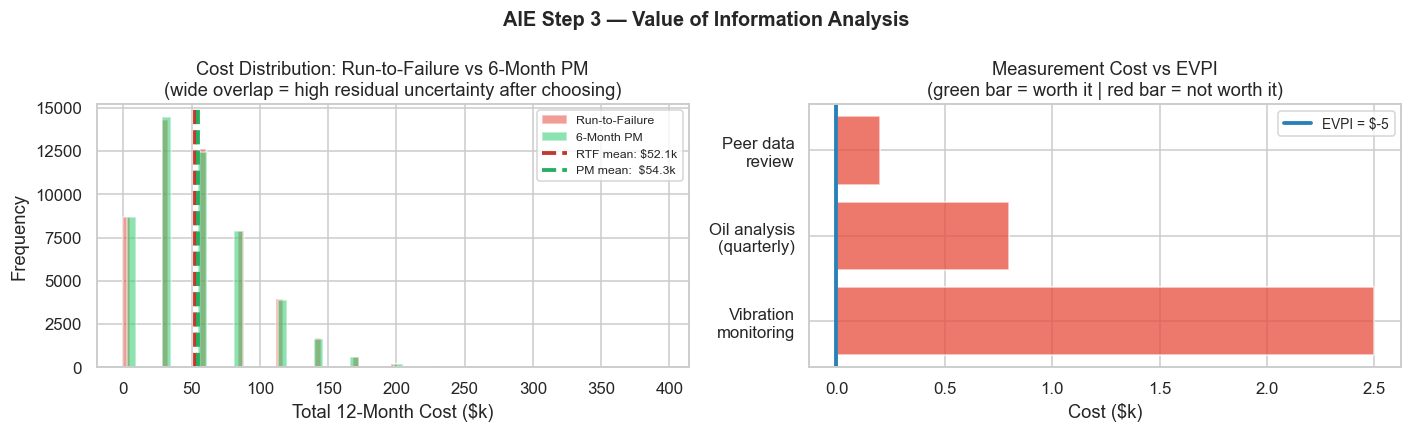

### How to Read This Section


| Quantity | Value | What it means |
|---|---|---|
| Best strategy (current data) | Fixed 6-month scheduled maintenance | The lower expected-cost option given what we know now |
| E\[cost \| uncertainty\] | $52,143 | Expected cost if we commit to the best known strategy |
| E\[cost \| perfect info\] | $52,149 | Expected cost if we always knew the true failure rate |
| **EVPI** | **$-5** | **Maximum it is worth spending to learn the failure rate** |

**AIE Rule of Thumb**: only invest in more measurement if its cost < EVPI.  
Bars coloured green in the chart above are cost-justified; red bars are not.


In [ ]:
Section5_Step3_Plot_VoI()


---
## Section 6 — Step 4: Calibrated Priors (Two Paths)

AIE requires **calibrated probability estimates** — not guesses, not overconfident point values.  
This section shows both paths for seeding priors:

### Path A — Expert Estimate → 90% Confidence Interval → Distribution
Engineer provides a 90% CI ("I'm 90% confident the MTBF is between 8 and 16 months").  
We fit a distribution to that interval.

### Path B — Sample Data → MLE / Method of Moments → Distribution
We have observed failure times. We fit a distribution directly and test goodness-of-fit.

In [365]:
# ── PATH A: Expert Calibrated Estimate ─────────────────────────────────────────
# Engineer's 90% CI for MTBF: [8, 16] months
# → Convert to failure rate lambda = 1/MTBF
# → lambda CI: [1/16, 1/8] = [0.0625, 0.125] failures/month

mtbf_low_90  = 8    # months (5th percentile estimate)
mtbf_high_90 = 16   # months (95th percentile estimate)

lambda_low  = 1 / mtbf_high_90   # 0.0625
lambda_high = 1 / mtbf_low_90    # 0.125

# Fit Gamma distribution parameters to match the 90% CI
# Using method: find (alpha, beta) such that Gamma CDF at low = 0.05, high = 0.95
from scipy.optimize import minimize

def gamma_ci_loss(params):
    alpha, rate = params
    if alpha <= 0 or rate <= 0:
        return 1e10
    p5  = stats.gamma.ppf(0.05, a=alpha, scale=1/rate)
    p95 = stats.gamma.ppf(0.95, a=alpha, scale=1/rate)
    return (p5 - lambda_low)**2 + (p95 - lambda_high)**2

result = minimize(gamma_ci_loss, x0=[3.5, 35.0], method="Nelder-Mead")
alpha_expert, rate_expert = result.x
mean_expert = alpha_expert / rate_expert

print("PATH A — Expert Calibrated Prior:")
print(f"  MTBF 90% CI entered: [{mtbf_low_90}, {mtbf_high_90}] months")
print(f"  Lambda 90% CI:       [{lambda_low:.4f}, {lambda_high:.4f}] failures/month")
print(f"  Fitted Gamma:        alpha={alpha_expert:.2f}, rate={rate_expert:.2f}")
print(f"  Prior mean lambda:   {mean_expert:.4f} → implied MTBF = {1/mean_expert:.1f} months")

PATH A — Expert Calibrated Prior:
  MTBF 90% CI entered: [8, 16] months
  Lambda 90% CI:       [0.0625, 0.1250] failures/month
  Fitted Gamma:        alpha=22.95, rate=250.85
  Prior mean lambda:   0.0915 → implied MTBF = 10.9 months


In [366]:
# ── PATH B: Sample Data → Fitted Distribution ──────────────────────────────────
# Simulated historical inter-failure times (months) for demonstration.
# Replace with your actual data.

observed_times_to_failure = np.array([8.2, 11.5, 9.8, 14.1, 10.3, 7.6, 12.9, 8.8, 11.1, 9.4])

# Fit Exponential (1-parameter) and Weibull (2-parameter) — compare
exp_params    = stats.expon.fit(observed_times_to_failure, floc=0)
weibull_params = stats.weibull_min.fit(observed_times_to_failure, floc=0)

# Log-likelihood comparison (higher = better fit)
ll_exp     = np.sum(stats.expon.logpdf(observed_times_to_failure, *exp_params))
ll_weibull = np.sum(stats.weibull_min.logpdf(observed_times_to_failure, *weibull_params))

print("PATH B — Data-Fitted Prior:")
print(f"  Sample size: {len(observed_times_to_failure)} observed TTFs")
print(f"  Sample mean: {np.mean(observed_times_to_failure):.2f} months")
print()
print(f"  Exponential fit:  scale={exp_params[1]:.2f}  | log-likelihood={ll_exp:.2f}")
print(f"  Weibull fit:      shape={weibull_params[0]:.2f}, scale={weibull_params[2]:.2f} | log-likelihood={ll_weibull:.2f}")
print()
better = "Weibull" if ll_weibull > ll_exp else "Exponential"
print(f"  → {better} provides better fit (higher log-likelihood).")

# Weibull shape interpretation
k = weibull_params[0]
if k < 1:
    wear = "infant mortality / early-life failures (decreasing hazard)"
elif k == 1:
    wear = "random failures (constant hazard — memoryless)"
else:
    wear = "wear-out failures (increasing hazard — PM is beneficial)"
print(f"  Weibull shape k={k:.2f} → {wear}")

PATH B — Data-Fitted Prior:
  Sample size: 10 observed TTFs
  Sample mean: 10.37 months

  Exponential fit:  scale=10.37  | log-likelihood=-33.39
  Weibull fit:      shape=5.62, scale=11.20 | log-likelihood=-21.24

  → Weibull provides better fit (higher log-likelihood).
  Weibull shape k=5.62 → wear-out failures (increasing hazard — PM is beneficial)


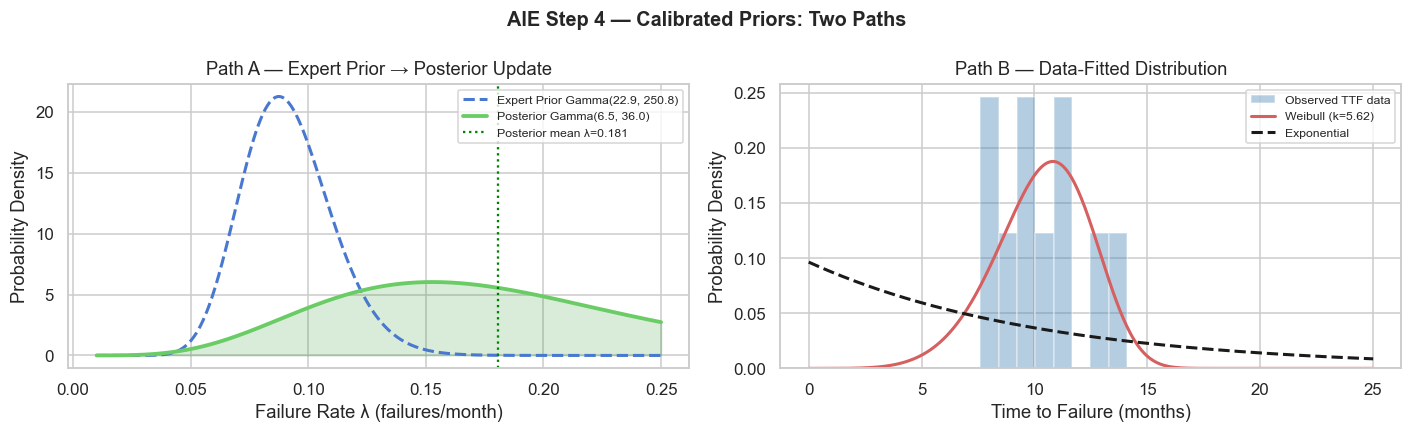

In [367]:
# ── PRIOR COMPARISON PLOT ──────────────────────────────────────────────────────
x = np.linspace(0.01, 0.25, 500)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Path A: Expert Gamma prior on lambda
prior_pdf = stats.gamma.pdf(x, a=alpha_expert, scale=1/rate_expert)
post_pdf  = stats.gamma.pdf(x, a=alpha_post,   scale=1/beta_post)
axes[0].plot(x, prior_pdf, "b--", lw=2, label=f"Expert Prior Gamma({alpha_expert:.1f}, {rate_expert:.1f})")
axes[0].plot(x, post_pdf,  "g-",  lw=2.5, label=f"Posterior Gamma({alpha_post:.1f}, {beta_post:.1f})")
axes[0].fill_between(x, post_pdf, alpha=0.15, color="green")
axes[0].axvline(alpha_post/beta_post, color="green", lw=1.5, linestyle=":",
                label=f"Posterior mean λ={alpha_post/beta_post:.3f}")
axes[0].set_xlabel("Failure Rate λ (failures/month)")
axes[0].set_ylabel("Probability Density")
axes[0].set_title("Path A — Expert Prior → Posterior Update")
axes[0].legend(fontsize=8)

# Path B: Weibull fit on TTF data
t = np.linspace(0, 25, 500)
weibull_pdf = stats.weibull_min.pdf(t, *weibull_params)
exp_pdf     = stats.expon.pdf(t, *exp_params)
axes[1].hist(observed_times_to_failure, bins=8, density=True, alpha=0.4,
             color="steelblue", label="Observed TTF data")
axes[1].plot(t, weibull_pdf, "r-",  lw=2, label=f"Weibull (k={weibull_params[0]:.2f})")
axes[1].plot(t, exp_pdf,     "k--", lw=2, label="Exponential")
axes[1].set_xlabel("Time to Failure (months)")
axes[1].set_ylabel("Probability Density")
axes[1].set_title("Path B — Data-Fitted Distribution")
axes[1].legend(fontsize=8)

plt.suptitle("AIE Step 4 — Calibrated Priors: Two Paths", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Section 7 — Step 5: Bayesian Update (PyMC Model)

We now build the full probabilistic model in **PyMC**, which:
- Encodes the prior on failure rate
- Conditions on observed failure count (likelihood)
- Samples the posterior via MCMC (NUTS sampler)

This is equivalent to the analytical Gamma-Poisson conjugate result, but generalizable to any prior/likelihood combination.

$$\underbrace{P(\lambda \mid k, t)}_{\text{posterior}} \propto \underbrace{\text{Poisson}(k \mid \lambda t)}_{\text{likelihood}} \cdot \underbrace{\text{Gamma}(\lambda \mid \alpha, \beta)}_{\text{prior}}$$

In [368]:
# ── PyMC BAYESIAN MODEL ────────────────────────────────────────────────────────
# Prior: Gamma(alpha, beta) on failure rate
# Likelihood: Poisson(lambda * t) observed k failures

obs_failures = decision_frame["observed_failures"]
obs_months   = decision_frame["observation_period_months"]

with pm.Model() as reliability_model:

    # Prior on failure rate (from expert calibration — Path A)
    lambda_rate = pm.Gamma(
        "lambda_rate",
        alpha=alpha_expert,
        beta=rate_expert,
        initval=mean_expert
    )

    # Likelihood: observed failure count over observation period
    failures_observed = pm.Poisson(
        "failures_observed",
        mu=lambda_rate * obs_months,
        observed=obs_failures
    )

    # Posterior predictive: expected failures under each strategy
    fail_rtf = pm.Poisson("fail_rtf", mu=lambda_rate * HORIZON)
    fail_pm  = pm.Poisson("fail_pm",  mu=lambda_rate * PM_CYCLE * N_PM)

    # Sample posterior
    trace = pm.sample(
        draws=2000,
        tune=1000,
        target_accept=0.9,
        progressbar=True,
        return_inferencedata=True,
        random_seed=42
    )

print("\nBayesian sampling complete.")

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [lambda_rate]
>CompoundStep
>>Metropolis: [fail_rtf]
>>Metropolis: [fail_pm]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 78 seconds.



Bayesian sampling complete.


### Increment B — Dynamic Model Builder & Prior Sensitivity Analysis

This subsection demonstrates two key concepts running in parallel.

**1. Dynamic Model Builder**
Reads the validated JSON contract from the LLM parser and automatically constructs a PyMC Bayesian model — no hand-coding required.  
This is the mechanism that makes the notebook reusable across different problem descriptions.

**2. Prior Sensitivity Analysis (AIE Teaching Moment)**
The same observed data (3 failures in 24 months) is updated through two different prior beliefs:

| Model | Prior Source | What it encodes |
|---|---|---|
| Hardcoded (Section 7) | Expert 90% CI fitting | Engineer's calibrated belief from MTBF range [8–16 months] |
| Dynamic (Increment B) | LLM-parsed JSON parameters | LLM's translated belief from the problem description |

Comparing their posteriors answers a core AIE question:

> **How sensitive is the decision recommendation to the choice of prior?**

- If posteriors are close → data dominates → the recommendation is robust regardless of prior.
- If posteriors diverge substantially → the prior matters → stronger elicitation or more data is warranted before deciding.

In [370]:
# ── DYNAMIC BUILDER MVP: GAMMA-POISSON ────────────────────────────────────────
# Builds a PyMC model from validated JSON metadata for the approved MVP family.

model_json_for_builder = bayesian_model_json if 'bayesian_model_json' in globals() else OFFLINE_JSON

required_profile = model_json_for_builder.get('profile', 'reliability')
if required_profile != 'reliability':
    raise ValueError(f"Increment B MVP currently supports profile='reliability', got '{required_profile}'")


def normalize_family(name: str) -> str:
    return str(name or '').strip().lower().replace('_', '').replace('-', '')


def find_gamma_poisson_pair(model_json: dict):
    nodes = model_json.get('measurement_nodes', [])
    prior_nodes_local = [
        n for n in nodes
        if n.get('role') == 'prior' and normalize_family(n.get('distribution_family')) == 'gamma'
    ]
    likelihood_nodes_local = [
        n for n in nodes
        if n.get('role') == 'likelihood' and normalize_family(n.get('distribution_family')) == 'poisson'
    ]
    return prior_nodes_local, likelihood_nodes_local


prior_nodes, likelihood_nodes = find_gamma_poisson_pair(model_json_for_builder)
json_source_name = 'bayesian_model_json'

# Graceful fallback if the parsed model is a different family (e.g., linear Normal model)
if not prior_nodes or not likelihood_nodes:
    print('Parsed JSON is valid but not Gamma-Poisson; switching Increment B MVP to OFFLINE_JSON fallback.')
    model_json_for_builder = OFFLINE_JSON
    prior_nodes, likelihood_nodes = find_gamma_poisson_pair(model_json_for_builder)
    json_source_name = 'OFFLINE_JSON'

if not prior_nodes or not likelihood_nodes:
    raise ValueError('No Gamma prior + Poisson likelihood pair found in either parsed JSON or OFFLINE_JSON.')

# For MVP we use the first matching prior/likelihood pair.
prior_node = prior_nodes[0]
likelihood_node = likelihood_nodes[0]

params = prior_node.get('distribution_parameters', {})
alpha_prior = float(params.get('alpha', 3.5))
if 'beta' in params:
    beta_prior = float(params['beta'])
elif 'rate' in params:
    beta_prior = float(params['rate'])
elif 'scale' in params and float(params['scale']) > 0:
    beta_prior = 1.0 / float(params['scale'])
else:
    beta_prior = 12.0

obs_failures_dyn = int(decision_frame['observed_failures'])
obs_months_dyn = int(decision_frame['observation_period_months'])

print('Dynamic builder inputs:')
print(f"  source JSON: {json_source_name}")
print(f"  prior node: {prior_node['name']} -> Gamma(alpha={alpha_prior}, beta={beta_prior})")
print(f"  likelihood node: {likelihood_node['name']} -> Poisson(mu=lambda_rate * {obs_months_dyn})")

with pm.Model() as reliability_model_dynamic:
    lambda_rate = pm.Gamma(
        'lambda_rate',
        alpha=alpha_prior,
        beta=beta_prior,
        initval=alpha_prior / beta_prior,
    )

    failures_observed = pm.Poisson(
        'failures_observed',
        mu=lambda_rate * obs_months_dyn,
        observed=obs_failures_dyn,
    )

    trace_dynamic = pm.sample(
        draws=1500,
        tune=800,
        target_accept=0.9,
        progressbar=True,
        return_inferencedata=True,
        random_seed=42,
    )

print('Dynamic Gamma-Poisson sampling complete.')

Parsed JSON is valid but not Gamma-Poisson; switching Increment B MVP to OFFLINE_JSON fallback.
Dynamic builder inputs:
  source JSON: OFFLINE_JSON
  prior node: failure_rate_lambda -> Gamma(alpha=55.8637, beta=618.2945)
  likelihood node: observed_failures -> Poisson(mu=lambda_rate * 24)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lambda_rate]


Output()

Sampling 4 chains for 800 tune and 1_500 draw iterations (3_200 + 6_000 draws total) took 42 seconds.


Dynamic Gamma-Poisson sampling complete.


### Prior Sensitivity Analysis Results

,Prior source,Posterior mean λ,Implied MTBF (mo),90% HDI low,90% HDI high
Model,,,,,
Hardcoded (Expert 90% CI),Path A — calibrated from MTBF CI,0.095,10.5,0.063,0.124
Dynamic (LLM-parsed JSON),"JSON alpha=55.9, beta=618.3",0.091,11.0,0.072,0.111


Posterior mean difference: 0.0040 failures/month (4.2%)
Expert prior implied MTBF:  10.5 months
LLM prior implied MTBF:     11.0 months



**Prior Sensitivity: LOW**

> Both priors produce similar posteriors. The observed data dominated the Bayesian update. The decision recommendation is robust — prior choice does not matter much here.

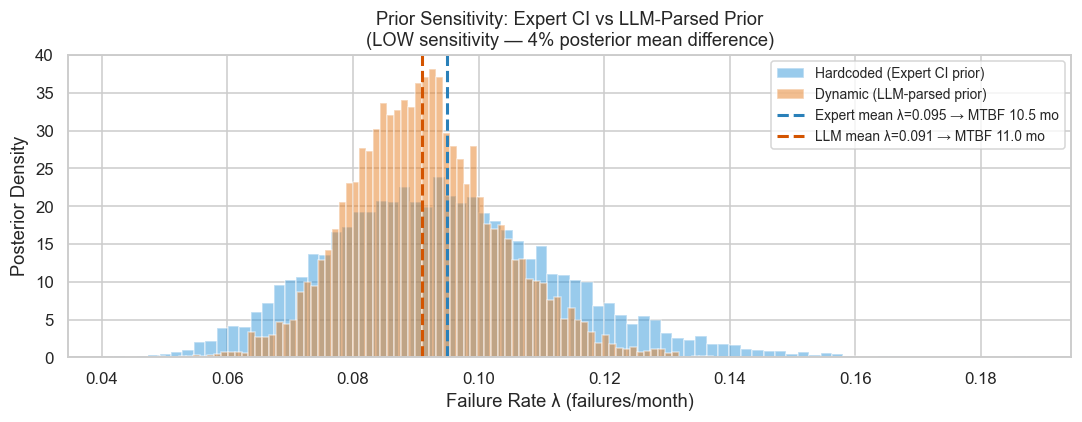

In [371]:
# ── PRIOR SENSITIVITY COMPARISON ──────────────────────────────────────────────
# Compares the hardcoded expert-calibrated posterior against the dynamic
# LLM-seeded posterior to show how much the choice of prior affects the result.

if 'trace' not in globals():
    raise ValueError('Run the Section 7 hardcoded PyMC model cell first.')
if 'trace_dynamic' not in globals():
    raise ValueError('Run the Increment B dynamic builder cell first.')

hc  = az.summary(trace,         var_names=['lambda_rate'], hdi_prob=0.9)
dyn = az.summary(trace_dynamic, var_names=['lambda_rate'], hdi_prob=0.9)

hc_mean  = float(hc.loc['lambda_rate',  'mean'])
dyn_mean = float(dyn.loc['lambda_rate', 'mean'])
hc_lo    = float(hc.loc['lambda_rate',  'hdi_5%'])
hc_hi    = float(hc.loc['lambda_rate',  'hdi_95%'])
dyn_lo   = float(dyn.loc['lambda_rate', 'hdi_5%'])
dyn_hi   = float(dyn.loc['lambda_rate', 'hdi_95%'])
abs_diff = abs(hc_mean - dyn_mean)
pct_diff = abs_diff / hc_mean * 100

display(Markdown('### Prior Sensitivity Analysis Results'))
display(pd.DataFrame({
    'Model':              ['Hardcoded (Expert 90% CI)', 'Dynamic (LLM-parsed JSON)'],
    'Prior source':       ['Path A — calibrated from MTBF CI', f'JSON alpha={alpha_prior:.1f}, beta={beta_prior:.1f}'],
    'Posterior mean λ':   [round(hc_mean, 4),  round(dyn_mean, 4)],
    'Implied MTBF (mo)':  [round(1/hc_mean, 1), round(1/dyn_mean, 1)],
    '90% HDI low':        [round(hc_lo, 4),  round(dyn_lo, 4)],
    '90% HDI high':       [round(hc_hi, 4),  round(dyn_hi, 4)],
}).set_index('Model'))

# ── INTERPRETATION GUIDANCE ────────────────────────────────────────────────────
# Thresholds: <10% = low, 10–30% = moderate, >30% = high sensitivity.
if pct_diff < 10:
    sensitivity = 'LOW'
    interpretation = (
        'Both priors produce similar posteriors. '
        'The observed data dominated the Bayesian update. '
        'The decision recommendation is robust — prior choice does not matter much here.'
    )
elif pct_diff < 30:
    sensitivity = 'MODERATE'
    interpretation = (
        'The two priors produce noticeably different posteriors. '
        'The decision recommendation may shift depending on which prior is used. '
        'AIE action: invest in better prior elicitation (e.g., expert interviews or historical data) '
        'or collect more observations before committing to a strategy.'
    )
else:
    sensitivity = 'HIGH'
    interpretation = (
        'The two priors produce substantially different posteriors and likely different decision recommendations. '
        'Prior choice is the dominant driver of the result — the data alone is insufficient to resolve the uncertainty. '
        'AIE action: this is a high-VoI situation. '
        'Better elicitation, additional measurements, or a pilot study is strongly warranted before deciding.'
    )

print(f'Posterior mean difference: {abs_diff:.4f} failures/month ({pct_diff:.1f}%)')
print(f'Expert prior implied MTBF:  {1/hc_mean:.1f} months')
print(f'LLM prior implied MTBF:     {1/dyn_mean:.1f} months')
print()
display(Markdown(f'**Prior Sensitivity: {sensitivity}**'))
display(Markdown(f'> {interpretation}'))

# ── VISUAL COMPARISON ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(trace.posterior['lambda_rate'].values.flatten(),
        bins=80, density=True, alpha=0.5, color='#3498db',
        label='Hardcoded (Expert CI prior)')
ax.hist(trace_dynamic.posterior['lambda_rate'].values.flatten(),
        bins=80, density=True, alpha=0.5, color='#e67e22',
        label='Dynamic (LLM-parsed prior)')
ax.axvline(hc_mean,  color='#2980b9', lw=2, linestyle='--',
           label=f'Expert mean λ={hc_mean:.3f} → MTBF {1/hc_mean:.1f} mo')
ax.axvline(dyn_mean, color='#d35400', lw=2, linestyle='--',
           label=f'LLM mean λ={dyn_mean:.3f} → MTBF {1/dyn_mean:.1f} mo')
ax.set_xlabel('Failure Rate λ (failures/month)')
ax.set_ylabel('Posterior Density')
ax.set_title(
    f'Prior Sensitivity: Expert CI vs LLM-Parsed Prior\n'
    f'({sensitivity} sensitivity — {pct_diff:.0f}% posterior mean difference)'
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
lambda_rate,0.0946,0.0188,0.0596,0.129,0.0004,0.0002,2033.2363,3534.6556,1.0007



Analytical posterior mean λ: 0.1806 → MTBF = 5.5 months
MCMC posterior mean λ:       0.0946 → MTBF = 10.6 months
Difference:                  0.08596 (should be ~0 for conjugate model)


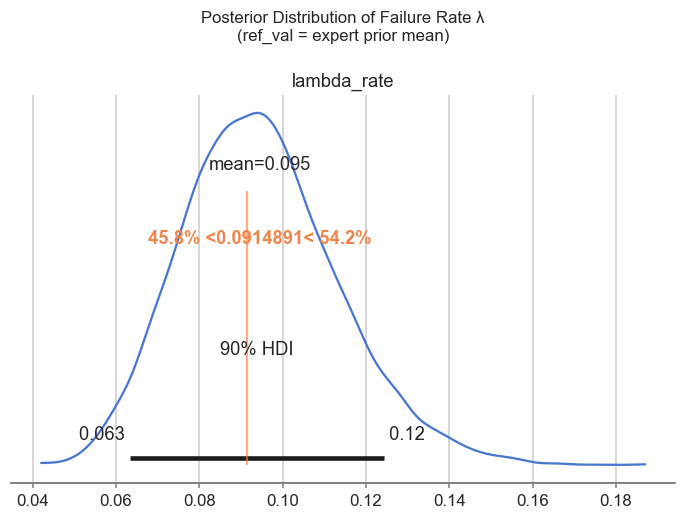

In [372]:
# ── POSTERIOR SUMMARY ─────────────────────────────────────────────────────────
summary = az.summary(trace, var_names=["lambda_rate"], round_to=4)
display(summary)

# Compare analytical vs MCMC posterior
lambda_post_mean_analytical = alpha_post / beta_post
lambda_post_mean_mcmc       = float(trace.posterior["lambda_rate"].mean())

print(f"\nAnalytical posterior mean λ: {lambda_post_mean_analytical:.4f} → MTBF = {1/lambda_post_mean_analytical:.1f} months")
print(f"MCMC posterior mean λ:       {lambda_post_mean_mcmc:.4f} → MTBF = {1/lambda_post_mean_mcmc:.1f} months")
print(f"Difference:                  {abs(lambda_post_mean_analytical - lambda_post_mean_mcmc):.5f} (should be ~0 for conjugate model)")

# Posterior plot
az.plot_posterior(trace, var_names=["lambda_rate"],
                  hdi_prob=0.9,
                  point_estimate="mean",
                  ref_val=mean_expert)
plt.suptitle("Posterior Distribution of Failure Rate λ\n(ref_val = expert prior mean)",
             fontsize=11)
plt.tight_layout()
plt.show()

---
## Section 8 — Step 5b: Chained Bayesian DAG Visualization

The JSON from Section 4 defines a **Directed Acyclic Graph (DAG)** — a chain of dependencies  
from raw measurements → derived quantities → cost outputs.

This visualization shows exactly **where each piece of information enters the model**.

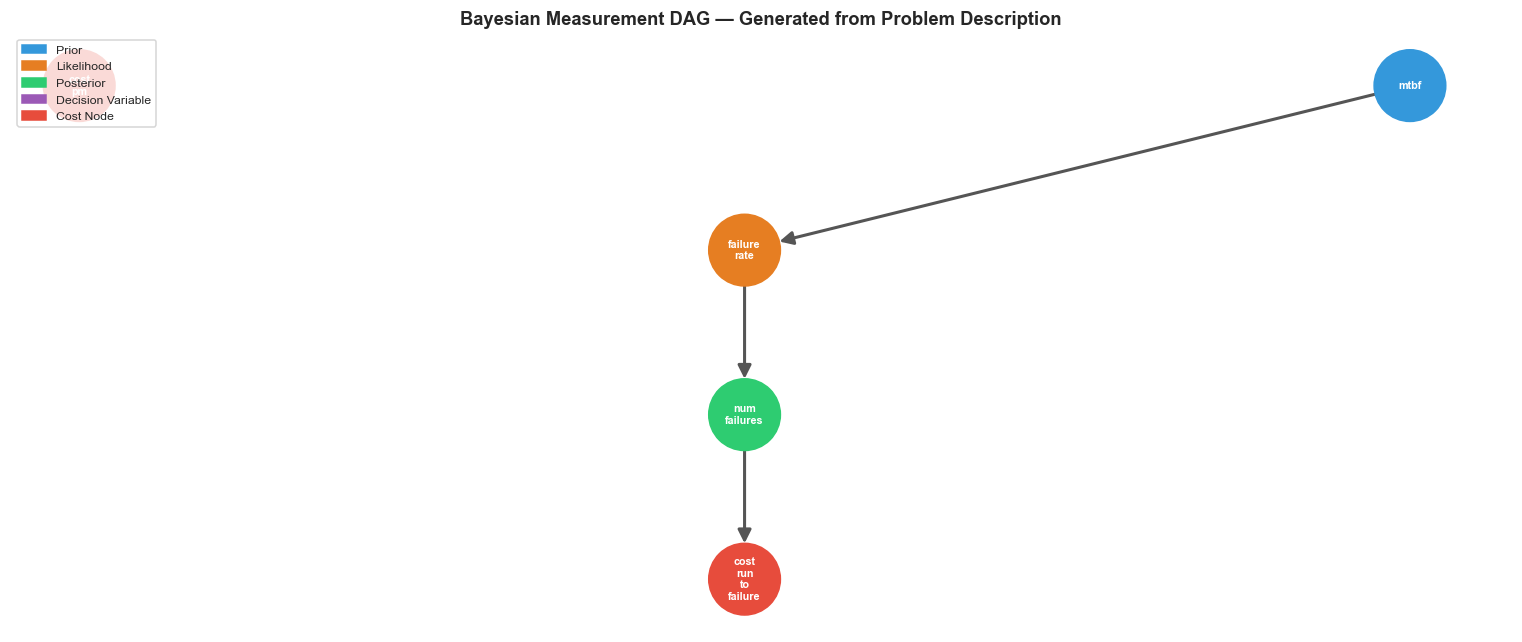

**Bayesian Update Chain:** `mtbf` → `failure_rate` → `num_failures` → `cost_run_to_failure` → `cost_pm`

In [373]:
# ── DAG VISUALIZATION FROM JSON MODEL ─────────────────────────────────────────
# Build NetworkX graph from the LLM-generated JSON

model_json = bayesian_model_json if "bayesian_model_json" in dir() else OFFLINE_JSON

G = nx.DiGraph()

# Color coding by node role
role_colors = {
    "prior":            "#3498db",   # blue
    "likelihood":       "#e67e22",   # orange
    "posterior":        "#2ecc71",   # green
    "decision_variable":"#9b59b6",   # purple
    "cost_node":        "#e74c3c",   # red
}

nodes      = model_json["measurement_nodes"]
node_names = {n["name"] for n in nodes}

for node in nodes:
    G.add_node(node["name"],
               role=node["role"],
               label=node["name"].replace("_", "\n"))

for node in nodes:
    for dep in node.get("depends_on", []):
        if dep in node_names:
            G.add_edge(dep, node["name"])

# Layout: hierarchical top-down by topological generation (pure-Python, no Graphviz needed)
def hierarchical_layout(graph: nx.DiGraph) -> dict:
    """Top-down layered layout based on longest path from any root."""
    depth = {}
    for n in nx.topological_sort(graph):
        preds = list(graph.predecessors(n))
        depth[n] = 0 if not preds else max(depth[p] for p in preds) + 1
    layers: dict[int, list[str]] = {}
    for node, d in depth.items():
        layers.setdefault(d, []).append(node)
    pos = {}
    max_width = max(len(row) for row in layers.values())
    for d, row in layers.items():
        row_sorted = sorted(row)
        for i, node in enumerate(row_sorted):
            x = (i + 1) / (len(row_sorted) + 1) * max_width
            y = -d  # negative so root is on top
            pos[node] = (x, y)
    return pos

try:
    pos = nx.nx_agraph.graphviz_layout(G, prog="dot")
except (ImportError, Exception):
    pos = hierarchical_layout(G)

colors = [role_colors.get(G.nodes[n]["role"], "#95a5a6") for n in G.nodes]
labels = {n: G.nodes[n]["label"] for n in G.nodes}

fig, ax = plt.subplots(figsize=(14, 6))
nx.draw_networkx(
    G, pos=pos, ax=ax,
    labels=labels,
    node_color=colors,
    node_size=2200,
    font_size=7,
    font_color="white",
    font_weight="bold",
    edge_color="#555",
    arrows=True,
    arrowsize=18,
    width=2,
)

# Legend
legend_patches = [mpatches.Patch(color=v, label=k.replace("_", " ").title())
                  for k, v in role_colors.items()]
ax.legend(handles=legend_patches, loc="upper left", fontsize=8)
ax.set_title("Bayesian Measurement DAG — Generated from Problem Description",
             fontsize=12, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

# Print chain
chain = model_json["bayesian_update_chain"]
display(Markdown("**Bayesian Update Chain:** " + " → ".join(f"`{n}`" for n in chain)))

---
## Section 9 — Step 7: Monte Carlo Simulation & Decision Recommendation

Propagate posterior uncertainty through the cost model to produce a **full cost distribution**  
for each strategy, and generate an **auditable decision recommendation**.

In [374]:
# ── MONTE CARLO COST PROPAGATION ───────────────────────────────────────────────
# Draw lambda samples from PyMC posterior trace

lambda_posterior_samples = trace.posterior["lambda_rate"].values.flatten()
N = len(lambda_posterior_samples)
rng2 = np.random.default_rng(seed=99)

# Simulate failure counts under each strategy
k_rtf  = rng2.poisson(lambda_posterior_samples * HORIZON)
k_pm   = rng2.poisson(lambda_posterior_samples * PM_CYCLE * N_PM)

# Total cost
total_cost_rtf = k_rtf * C_FAIL
total_cost_pm  = (N_PM * C_PM) + k_pm * C_FAIL

# Summary statistics
results = pd.DataFrame({
    "Strategy":     ["Run-to-Failure", "6-Month PM"],
    "Mean Cost ($)": [np.mean(total_cost_rtf), np.mean(total_cost_pm)],
    "Median ($)":   [np.median(total_cost_rtf), np.median(total_cost_pm)],
    "P10 ($)":      [np.percentile(total_cost_rtf, 10), np.percentile(total_cost_pm, 10)],
    "P90 ($)":      [np.percentile(total_cost_rtf, 90), np.percentile(total_cost_pm, 90)],
    "P(cheaper) %": [
        np.mean(total_cost_rtf < total_cost_pm) * 100,
        np.mean(total_cost_pm  < total_cost_rtf) * 100
    ]
})
results = results.set_index("Strategy")
dollar_cols = ["Mean Cost ($)", "Median ($)", "P10 ($)", "P90 ($)"]
for col in dollar_cols:
    results[col] = results[col].map(lambda v: f"${v:,.0f}")
results["P(cheaper) %"] = results["P(cheaper) %"].map(lambda v: f"{v:.1f}%")

display(Markdown("### Monte Carlo Cost Summary"))
display(results)

### Monte Carlo Cost Summary

,Mean Cost ($),Median ($),P10 ($),P90 ($),P(cheaper) %
Strategy,,,,,
Run-to-Failure,"$20,608","$18,000",$0,"$54,000",63.8%
6-Month PM,"$24,688","$22,400","$4,400","$58,400",36.2%


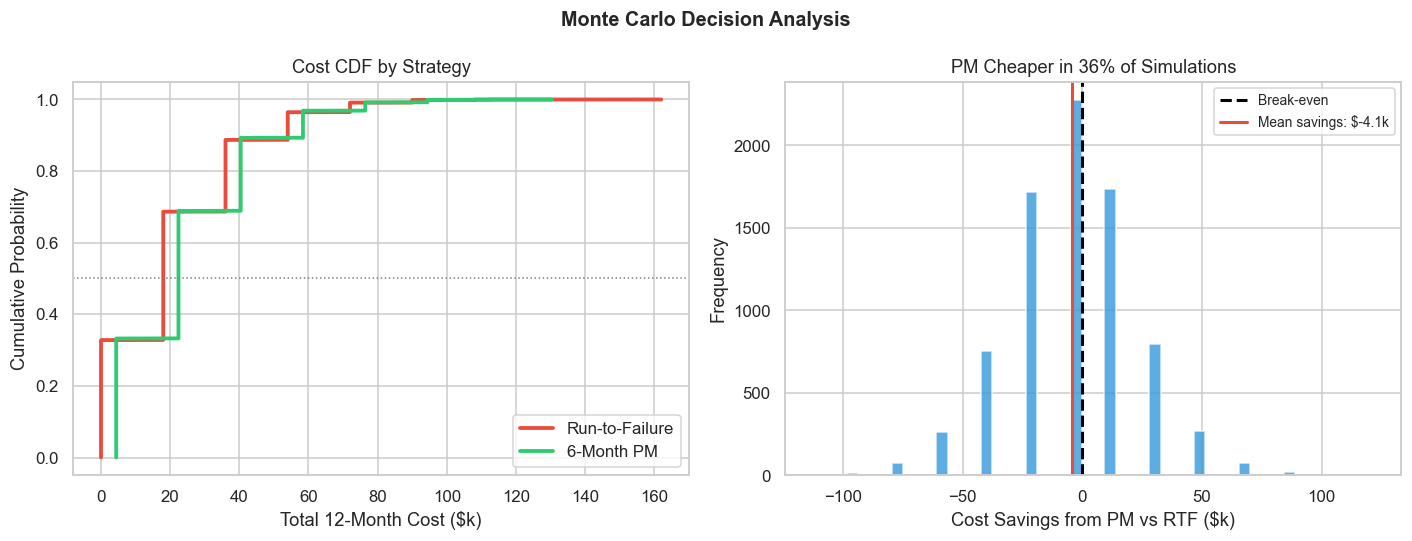


---
### Decision Recommendation

**Recommended Strategy**: **Run-to-Failure**

- PM is the lower-cost strategy in **36%** of simulated scenarios.
- Expected savings from PM over 12 months: **$-4,080**
- EVPI = **$-55** — additional investment in failure-rate characterization  
  (e.g., vibration monitoring) is not required.

*This recommendation is based on 8,000 posterior draws and 8,000 Monte Carlo simulations.*


In [375]:
# ── DECISION VISUALIZATION ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Cost CDFs
for cost, label, color in [
    (total_cost_rtf, "Run-to-Failure", "#e74c3c"),
    (total_cost_pm,  "6-Month PM",     "#2ecc71")
]:
    sorted_cost = np.sort(cost)
    cdf = np.arange(1, len(sorted_cost)+1) / len(sorted_cost)
    axes[0].plot(sorted_cost/1000, cdf, lw=2.5, label=label, color=color)

axes[0].set_xlabel("Total 12-Month Cost ($k)")
axes[0].set_ylabel("Cumulative Probability")
axes[0].set_title("Cost CDF by Strategy")
axes[0].axhline(0.5, color="gray", linestyle=":", lw=1)
axes[0].legend()

# Savings distribution
savings = total_cost_rtf - total_cost_pm
axes[1].hist(savings/1000, bins=50, color="#3498db", edgecolor="white", alpha=0.8)
axes[1].axvline(0, color="black", lw=2, linestyle="--", label="Break-even")
axes[1].axvline(np.mean(savings)/1000, color="#e74c3c", lw=2,
                label=f"Mean savings: ${np.mean(savings)/1000:.1f}k")
pct_pm_wins = np.mean(savings > 0) * 100
axes[1].set_xlabel("Cost Savings from PM vs RTF ($k)")
axes[1].set_ylabel("Frequency")
axes[1].set_title(f"PM Cheaper in {pct_pm_wins:.0f}% of Simulations")
axes[1].legend(fontsize=9)

plt.suptitle("Monte Carlo Decision Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── RECOMMENDATION ────────────────────────────────────────────────────────────
mean_savings = np.mean(savings)
rec = "6-Month Preventive Maintenance" if mean_savings > 0 else "Run-to-Failure"
display(Markdown(f"""
---
### Decision Recommendation

**Recommended Strategy**: **{rec}**

- PM is the lower-cost strategy in **{pct_pm_wins:.0f}%** of simulated scenarios.
- Expected savings from PM over 12 months: **${mean_savings:,.0f}**
- EVPI = **${EVPI:,.0f}** — additional investment in failure-rate characterization  
  (e.g., vibration monitoring) is {'justified' if EVPI > 500 else 'not required'}.

*This recommendation is based on {N:,} posterior draws and {N:,} Monte Carlo simulations.*
"""))

---
## Section 10 — Your Turn: Participant Exercise

Replace the decision frame below with **your own reliability problem**.  
The LLM will map it into a Bayesian structure automatically.

**Suggested exercise scenarios:**
1. A conveyor belt system with 5 failures over 18 months — decide on predictive vs. scheduled maintenance.
2. A safety valve with no failures in 36 months — is the current inspection interval adequate?
3. A fleet of 12 motors with mixed failure history — prioritize which unit to maintain first.

---
### ## YOUR TURN — Edit the cell below

In [ ]:
# ── PARTICIPANT EXERCISE ───────────────────────────────────────────────────────
# Replace the values below with your own problem.
# Then re-run ALL cells from Section 3 onward.

my_decision_frame = {
    "problem_description": """
        << DESCRIBE YOUR RELIABILITY PROBLEM HERE >>
        Include: asset type, failure history, costs, time horizon, and decision options.
    """,
    "decision_options": [
        "Option A",
        "Option B"
    ],
    "objective": "Minimize expected cost over the planning horizon",
    "time_horizon_months": 12,
    "cost_pm_per_intervention_usd": 0,     # Replace with your PM cost
    "cost_unplanned_failure_usd": 0,       # Replace with your failure cost
    "observed_failures": 0,                # Replace with observed failure count
    "observation_period_months": 12,       # Replace with observation duration
    "industry_mtbf_range_months": [6, 18], # Replace with your 90% CI on MTBF
}

# Uncomment to use your frame and re-run from Section 3:
# decision_frame = my_decision_frame
# bayesian_model_json = parse_problem_to_json(my_decision_frame["problem_description"])
# print(json.dumps(bayesian_model_json, indent=2))

print("Exercise template ready. Fill in the fields above and uncomment the last lines.")

Exercise template ready. Fill in the fields above and uncomment the last lines.


---
## References

1. **Hubbard, D.** (2014). *How to Measure Anything: Finding the Value of Intangibles in Business* (3rd ed.). Wiley.
2. **Hubbard, D.** (2025). *How to Measure Anything in AI: Quantitative Techniques for Decision-Making*. LinkedIn Learning.
3. **LLM-BI**: *Towards Fully Automated Bayesian Inference with Large Language Models*. arXiv:2508.08300 (Aug 2025).
4. **Lorenz & Fritz** (2026). *Scalable Delphi: LLM-Assisted Expert Elicitation for Calibrated Priors*. arXiv (Feb 2026).
5. **Salvatier, J., Wiecki, T., Fonnesbeck, C.** (2016). Probabilistic programming in Python using PyMC3. *PeerJ Computer Science*.
6. **Kumar & Klefsjö** (1994). Proportional hazards model: a review. *Reliability Engineering & System Safety*, 44(2), 177-188.

---
*Notebook version 1.0 — RAMS 2027 Tutorial Submission*  
*Author: Kirtis Christensen | Bayesian Mentor: Grok (xAI)*  
*Generated: April 30, 2026*